# Unsupervised Anomaly Detection for Cybersecurity: A Comparative Study on UNSW-NB15

## 1. Introduzione

Il rilevamento di attacchi **zero-day** e minacce sconosciute richiede sistemi di
**Anomaly Detection (AD)** capaci di operare senza esempi di attacco etichettati.
Questo notebook adotta il paradigma **Novelty Detection**: i modelli apprendono
esclusivamente il comportamento benigno della rete, e qualsiasi deviazione
significativa viene classificata come anomalia a inference time.

Vengono confrontati sei modelli — dalle tecniche classiche (**PCA**, **K-Means**,
**OCSVM**, **Isolation Forest**) alla Deep Learning (**Simple Autoencoder**,
**Advanced Autoencoder**) — applicati al dataset **UNSW-NB15**. Le feature vengono
selezionate tramite mappatura al framework **MITRE ATT&CK** e affinate con
un'analisi di **feature distillation** basata su soglia di correlazione di Pearson.
A conclusione del notebook, un classificatore **XGBoost** supervisionato stabilisce
il riferimento SOTA e quantifica il costo operativo dell'assenza delle etichette.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
import random
import tensorflow as tf

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/BigData_Project/Training_and_TestingSets/UNSW_NB15_training-set.csv'
test_path  = '/content/drive/MyDrive/BigData_Project/Training_and_TestingSets/UNSW_NB15_testing-set.csv'

print("\nCaricamento dei log di rete in corso, attendere...")
train_df_raw = pd.read_csv(train_path)
test_df_raw  = pd.read_csv(test_path)

print(f"✅ Training set caricato:  {train_df_raw.shape[0]} righe e {train_df_raw.shape[1]} colonne.")
print(f"✅ Testing set caricato:   {test_df_raw.shape[0]} righe e {test_df_raw.shape[1]} colonne.")

display(train_df_raw.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Caricamento dei log di rete in corso, attendere...
✅ Training set caricato:  175341 righe e 45 colonne.
✅ Testing set caricato:   82332 righe e 45 colonne.


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 2. Protocollo Sperimentale e Validation Split

Per garantire un protocollo rigoroso e prevenire il **Data Leakage**, il Test Set
viene mantenuto completamente isolato durante tutte le fasi: training, tuning e
calibrazione delle soglie operative.

Il training originale viene suddiviso in **Training Set** (80%) e **Validation Set**
(20%) tramite campionamento stratificato per preservare le proporzioni di classe.
Le label di categoria di attacco del Test Set (`attack_cat`) vengono salvate
separatamente per l'analisi post-hoc finale (Step 11).


In [35]:
from sklearn.model_selection import train_test_split

# Salviamo le categorie di attacco del test set per l'analisi post-hoc finale
attack_cat_test = test_df_raw['attack_cat'].copy()

# Split del training originale in Train e Validation (Stratificato per mantenere le proporzioni)
train_df, val_df = train_test_split(
    train_df_raw,
    test_size=0.2,
    random_state=42,
    stratify=train_df_raw['label']
)

print(f"Training Set part: {train_df.shape}")
print(f"Validation Set part: {val_df.shape}")
print(f"Testing Set part (Blind): {test_df_raw.shape}")

Training Set part: (140272, 45)
Validation Set part: (35069, 45)
Testing Set part (Blind): (82332, 45)


## 3. Data Cleaning ed Encoding

Le colonne identificative (`id`, `attack_cat`) vengono rimosse prima del training.
I valori mancanti e i placeholder (`-`) sono gestiti per tipo di colonna: le colonne
categoriche (`proto`, `service`, `state`) vengono imputate con `'unknown'`,
quelle numeriche con `0`.

Le variabili categoriche vengono trasformate con **One-Hot Encoding (OHE)**, fittato
esclusivamente sul Training Set e applicato via `transform` su Validation e Test Set
(anti-leakage). Al termine, il Training Set viene filtrato per contenere
**esclusivamente traffico benigno** (`label == 0`): i modelli impareranno solo il
comportamento normale della rete — 44.800 campioni su 192 feature.


In [36]:
from sklearn.preprocessing import OneHotEncoder

# Gestione valori mancanti — separata per tipo di colonna
for df in [train_df, val_df, test_df_raw]:
    df.replace('-', np.nan, inplace=True)
    # Colonne categoriche → 'unknown'
    for col in ['proto', 'service', 'state']:
        df[col].fillna('unknown', inplace=True)
    # Colonne numeriche → 0
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(0)

# Drop identificativi e attack_cat
cols_to_drop = ['id', 'attack_cat']
for df in [train_df, val_df, test_df_raw]:
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Separazione Label
y_train_full = train_df['label'].values
y_val        = val_df['label'].values
y_test       = test_df_raw['label'].values

train_df.drop(columns=['label'], inplace=True)
val_df.drop(columns=['label'], inplace=True)
test_df = test_df_raw.drop(columns=['label'])

# One-Hot Encoding — fit SOLO sul train, transform sugli altri (anti-leakage)
categorical_cols = ['proto', 'service', 'state']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_cat = ohe.fit_transform(train_df[categorical_cols])
val_cat   = ohe.transform(val_df[categorical_cols])
test_cat  = ohe.transform(test_df[categorical_cols])

# Ricostruzione DataFrame con OHE
train_df_num = train_df.drop(columns=categorical_cols).reset_index(drop=True)
val_df_num   = val_df.drop(columns=categorical_cols).reset_index(drop=True)
test_df_num  = test_df.drop(columns=categorical_cols).reset_index(drop=True)

train_df_encoded = pd.concat([train_df_num, pd.DataFrame(train_cat)], axis=1)
val_df_encoded   = pd.concat([val_df_num,   pd.DataFrame(val_cat)],   axis=1)
test_df_encoded  = pd.concat([test_df_num,  pd.DataFrame(test_cat)],  axis=1)

# Filtro: teniamo SOLO il traffico benigno nel training set (Novelty Detection)
train_df_encoded['label_tmp'] = y_train_full
X_train_benign = train_df_encoded[train_df_encoded['label_tmp'] == 0].drop(columns=['label_tmp']).copy()

print(f"Final Training set (Benign Only): {X_train_benign.shape}")


Final Training set (Benign Only): (44800, 192)


## 4. Feature Selection: MITRE ATT&CK TTPs

La selezione delle feature non si basa sulla correlazione statistica con la variabile
target — operazione che costituirebbe una forma di **supervised leakage** incompatibile
con il paradigma Novelty Detection. La selezione è invece guidata dal **Domain Knowledge**
e dal framework **MITRE ATT&CK**.

Vengono isolate **37 feature numeriche** i cui osservabili di network flow sono mappabili
a specifiche Tactics, Techniques and Procedures (TTPs) lungo la Cyber Kill Chain,
dalla Reconnaissance all'Impact. La mappatura TTP-to-feature dettagliata è riportata
nella tabella MITRE ATT&CK Threat Intelligence (Step 10).


In [37]:
features_mitre = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
    'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit',
    'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
    'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl',
    'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
    'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_srv_dst'
]

# Verifica difensiva
missing = [f for f in features_mitre if f not in X_train_benign.columns]
if missing:
    print(f"⚠️ Feature mancanti: {missing}")
else:
    print("✅ Tutte le 37 feature MITRE presenti.")

# Estrazione dai DF pre-OHE (feature numeriche originali)
X_train_mitre = X_train_benign[features_mitre]
X_val_mitre   = val_df_num[features_mitre]
X_test_mitre  = test_df_num[features_mitre]

print(f"Selected Features: {X_train_mitre.shape[1]}")


✅ Tutte le 37 feature MITRE presenti.
Selected Features: 37


## 5. Normalizzazione: Standard Scaler

La standardizzazione viene eseguita con **StandardScaler** (media zero, varianza unitaria),
fittato **esclusivamente sul Training Set benigno** e applicato via `transform` a
Validation e Test Set — nessuna informazione statistica del traffico anomalo o non visto
influenza i parametri di normalizzazione.

Il risultato sono tre matrici scalate: `X_train_scaled` (44.800 × 37),
`X_val_scaled` (35.069 × 37) e `X_test_scaled` (82.332 × 37), pronte per l'input
a tutti i modelli della pipeline.


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_mitre)
X_val_scaled   = scaler.transform(X_val_mitre)
X_test_scaled  = scaler.transform(X_test_mitre)

print(f"✅ Scaling completato.")
print(f"   X_train_scaled: {X_train_scaled.shape}")
print(f"   X_val_scaled:   {X_val_scaled.shape}")
print(f"   X_test_scaled:  {X_test_scaled.shape}")


✅ Scaling completato.
   X_train_scaled: (44800, 37)
   X_val_scaled:   (35069, 37)
   X_test_scaled:  (82332, 37)


## 6. Training dei Modelli Baseline (Parametri Default)

Prima di qualsiasi ottimizzazione, si stabilisce una **baseline di performance**
che fungerà da pavimento per la fase di tuning: una configurazione candidata verrà
accettata solo se migliora strettamente l'AUC baseline corrispondente.

I sei modelli vengono addestrati con parametri standard o euristici, esclusivamente
sul Training Set benigno. La **anomaly score convention** è uniforme per tutta la
pipeline: score più alto = più anomalo. La riproducibilità è garantita tramite seeding
globale (`random`, `numpy`, `tensorflow`) con `clear_session()` + reset del seed
prima di ogni modello Keras.


In [39]:
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os, random
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

print("Training Baseline Models on Benign Training Set...")
baseline_models = {}

# 1. Baseline PCA
baseline_models['PCA'] = PCA(n_components=30, random_state=42).fit(X_train_scaled)

# 2. Baseline K-Means
baseline_models['K-Means'] = MiniBatchKMeans(n_clusters=10, random_state=42, batch_size=2048, n_init="auto").fit(X_train_scaled)

# 3. Baseline OCSVM
baseline_models['OCSVM'] = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1).fit(X_train_scaled)

# 4. Baseline Isolation Forest
baseline_models['Isolation Forest'] = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1).fit(X_train_scaled)

# 5. Baseline Simple AE
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

input_dim = X_train_scaled.shape[1]
print(f"\n   input_dim: {input_dim} | X_train_scaled: {X_train_scaled.shape}")

ae_simple_base = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(24, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(24, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
ae_simple_base.compile(optimizer='adam', loss='mse')
ae_simple_base.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=256, verbose=0)
baseline_models['Simple AE'] = ae_simple_base

# 6. Baseline Advanced AE
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

ae_adv_base = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32), layers.BatchNormalization(), layers.LeakyReLU(0.1), layers.Dropout(0.2),
    layers.Dense(16), layers.BatchNormalization(), layers.LeakyReLU(0.1),
    layers.Dense(12, activation='relu'),
    layers.Dense(16), layers.BatchNormalization(), layers.LeakyReLU(0.1), layers.Dropout(0.2),
    layers.Dense(32), layers.BatchNormalization(), layers.LeakyReLU(0.1),
    layers.Dense(input_dim, activation='linear')
])
ae_adv_base.compile(optimizer='adam', loss='mse')
ae_adv_base.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=256, verbose=0)
baseline_models['Advanced AE'] = ae_adv_base

print("\nBaseline models training completed.")


Training Baseline Models on Benign Training Set...

   input_dim: 37 | X_train_scaled: (44800, 37)

Baseline models training completed.


## 7. Valutazione Baseline sul Validation Set

I modelli baseline vengono valutati sul **Validation Set** (traffico benigno +
attacchi) tramite **ROC-AUC** come metrica primaria — misura il potere discriminativo
indipendentemente da qualsiasi soglia fissa, adatta a dataset sbilanciati.
Come metrica secondaria viene calcolata anche la **PR-AUC** (Precision-Recall),
più informativa sulla capacità di rilevamento nelle classi minoritarie.

I valori AUC risultanti costituiscono il **floor per il tuning** (Step 8):
ogni configurazione candidata viene accettata solo se migliora strettamente
il corrispondente score baseline.


Evaluating Baseline Models on Validation Set...


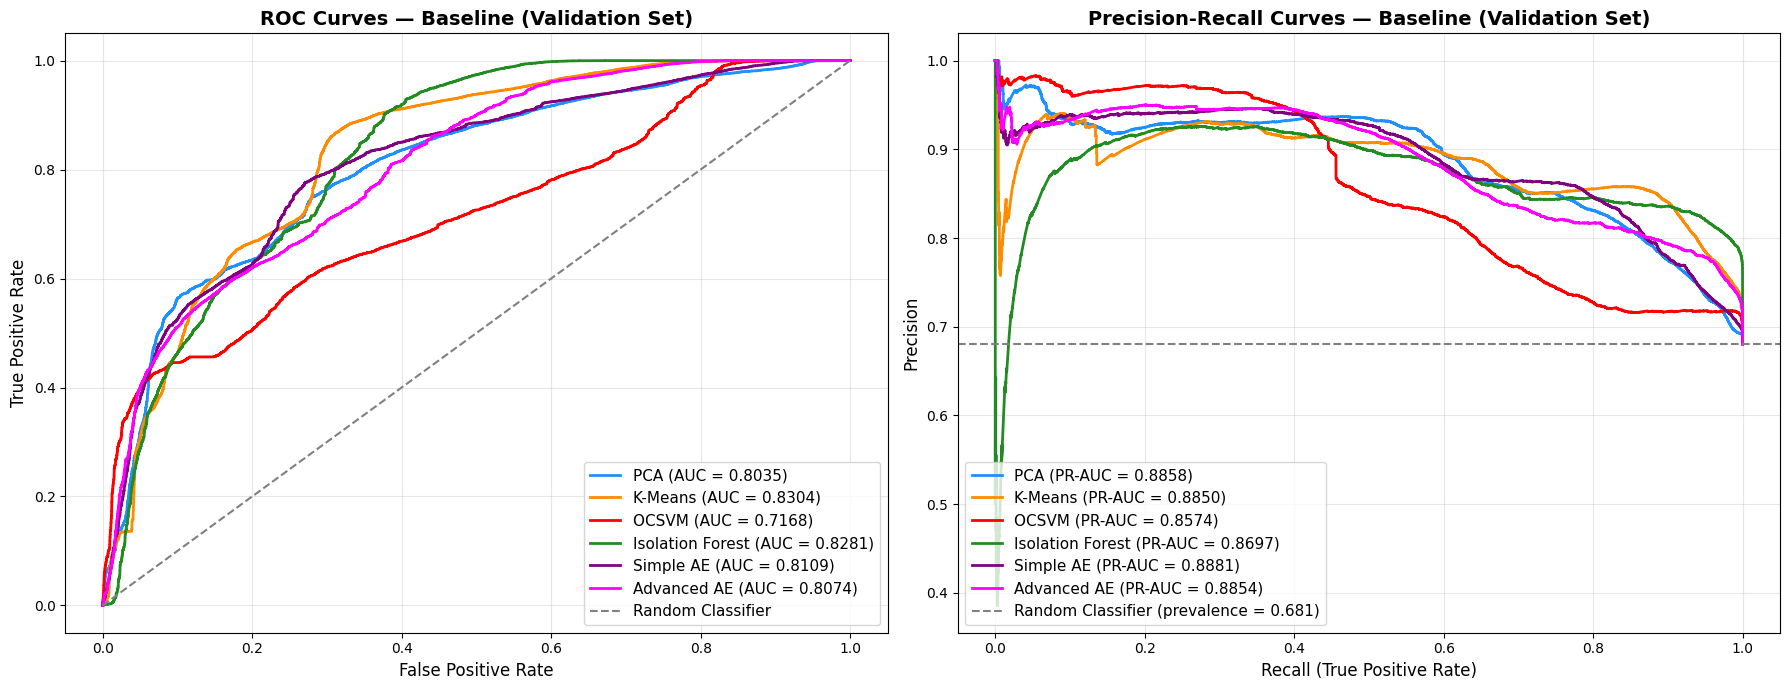

In [40]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score

print("Evaluating Baseline Models on Validation Set...")

baseline_val_scores = {
    'PCA':              np.mean(np.power(X_val_scaled - baseline_models['PCA'].inverse_transform(
                            baseline_models['PCA'].transform(X_val_scaled)), 2), axis=1),
    'K-Means':          np.min(baseline_models['K-Means'].transform(X_val_scaled), axis=1),
    'OCSVM':            -baseline_models['OCSVM'].decision_function(X_val_scaled),
    'Isolation Forest': -baseline_models['Isolation Forest'].score_samples(X_val_scaled),
    'Simple AE':        np.mean(np.power(X_val_scaled - baseline_models['Simple AE'].predict(
                            X_val_scaled, verbose=0), 2), axis=1),
    'Advanced AE':      np.mean(np.power(X_val_scaled - baseline_models['Advanced AE'].predict(
                            X_val_scaled, verbose=0), 2), axis=1)
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors_6 = ['dodgerblue', 'darkorange', 'red', 'forestgreen', 'purple', 'magenta']

for (name, score), color in zip(baseline_val_scores.items(), colors_6):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, score)
    roc_auc     = roc_auc_score(y_val, score)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2)

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_val, score)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})', color=color, lw=2)

# Formattazione ROC
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves — Baseline (Validation Set)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(alpha=0.3)

# Formattazione PR — baseline = prevalenza attacchi nel validation set
baseline_pr = y_val.mean()
ax2.axhline(y=baseline_pr, color='gray', linestyle='--',
            label=f'Random Classifier (prevalence = {baseline_pr:.3f})')
ax2.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves — Baseline (Validation Set)', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning sul Validation Set

Il tuning viene implementato come **manual grid search** sul Validation Set,
che rimane l'unico segnale di valutazione — il Test Set è ancora completamente
isolato. Per ogni modello viene esplorato uno spazio di configurazioni su
parametri chiave: numero di componenti (PCA), numero di cluster (K-Means),
griglia 2D nu×gamma (OCSVM), `n_estimators` e `max_samples` (Isolation Forest),
architettura e learning rate con **EarlyStopping** (entrambi gli Autoencoder).

I modelli selezionati e i delta AUC rispetto alla baseline sono visibili
nella tabella di riepilogo finale. Il miglioramento più significativo si
registra per il **Simple AE** (+0.0748), mentre **PCA** non supera la baseline
e mantiene i parametri di default.


--- ROBUST TUNING ON VALIDATION SET ---

Baseline Validation AUCs (floor per il tuning):
  PCA: 0.8035
  K-Means: 0.8304
  OCSVM: 0.7168
  Isolation Forest: 0.8281
  Simple AE: 0.8109
  Advanced AE: 0.8074

Tuning PCA...
Selected PCA -> baseline | Val AUC: 0.8035 | Time: 0.38s

Tuning K-Means...
Selected K-Means -> {'n_clusters': 20} | Val AUC: 0.8621 | Time: 2.65s

Tuning OCSVM...
Selected OCSVM -> {'nu': 0.01, 'gamma': 'scale'} | Val AUC: 0.7421 | Time: 229.93s

Tuning Isolation Forest...
Selected iForest -> {'n_estimators': 200, 'max_samples': 0.75, 'max_features': 1.0} | Val AUC: 0.8680 | Time: 16.73s

Tuning Simple AE...
Selected Simple AE -> {'h1': 48, 'h2': 24, 'lr': 0.0005, 'batch_size': 512, 'epochs': 60} | Val AUC: 0.8857 | Time: 104.80s

Tuning Advanced AE...
Selected Advanced AE -> {'d1': 32, 'd2': 16, 'bottleneck': 8, 'dropout': 0.1, 'lr': 0.0005, 'batch_size': 256, 'epochs': 100} | Val AUC: 0.8238 | Time: 296.87s


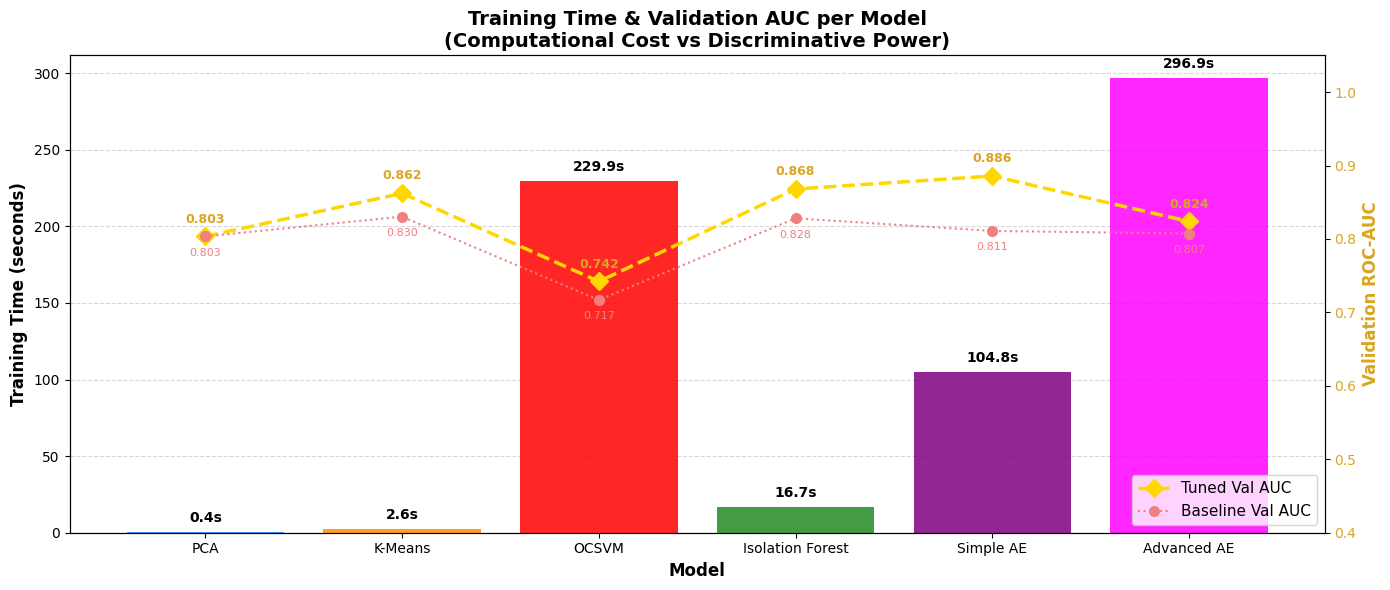


--- FINAL SELECTED MODELS ---


,Baseline AUC,Tuned AUC,Delta,Best Params,Training Time (s)
Model,,,,,
PCA,0.8035,0.8035,+0.0000,baseline,0.38
K-Means,0.8304,0.8621,+0.0317,{'n_clusters': 20},2.65
OCSVM,0.7168,0.7421,+0.0253,"{'nu': 0.01, 'gamma': 'scale'}",229.93
Isolation Forest,0.8281,0.8680,+0.0398,"{'n_estimators': 200, 'max_samples': 0.75, 'ma...",16.73
Simple AE,0.8109,0.8857,+0.0748,"{'h1': 48, 'h2': 24, 'lr': 0.0005, 'batch_size...",104.80
Advanced AE,0.8074,0.8238,+0.0164,"{'d1': 32, 'd2': 16, 'bottleneck': 8, 'dropout...",296.87


In [41]:
import gc
import random
import numpy as np
import time
import tensorflow as tf
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from tensorflow.keras import layers, models, callbacks, optimizers

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("--- ROBUST TUNING ON VALIDATION SET ---")

# ════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════
def pca_score(model, X):
    return np.mean((X - model.inverse_transform(model.transform(X))) ** 2, axis=1)

def kmeans_score(model, X):
    return np.min(model.transform(X), axis=1)

def ocsvm_score(model, X):
    return -model.decision_function(X)

def iforest_score(model, X):
    # score_samples: raw anomaly score senza offset da contamination
    return -model.score_samples(X)

def ae_score(model, X):
    return np.mean((X - model.predict(X, verbose=0)) ** 2, axis=1)

def build_simple_ae(input_dim, h1=24, h2=16, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(h1, activation='relu'),
        layers.Dense(h2, activation='relu'),
        layers.Dense(h1, activation='relu'),
        layers.Dense(input_dim, activation='linear')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse')
    return model

def build_advanced_ae(input_dim, d1=32, d2=16, bottleneck=12, dropout=0.2, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(d1), layers.BatchNormalization(), layers.LeakyReLU(0.1), layers.Dropout(dropout),
        layers.Dense(d2), layers.BatchNormalization(), layers.LeakyReLU(0.1),
        layers.Dense(bottleneck, activation='relu'),
        layers.Dense(d2), layers.BatchNormalization(), layers.LeakyReLU(0.1), layers.Dropout(dropout),
        layers.Dense(d1), layers.BatchNormalization(), layers.LeakyReLU(0.1),
        layers.Dense(input_dim, activation='linear')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse')
    return model

# ════════════════════════════════════════════════════════════════
# 0. BASELINE COME FLOOR — il tuning può solo migliorare
# ════════════════════════════════════════════════════════════════
baseline_val_auc = {
    'PCA':              roc_auc_score(y_val, pca_score(baseline_models['PCA'], X_val_scaled)),
    'K-Means':          roc_auc_score(y_val, kmeans_score(baseline_models['K-Means'], X_val_scaled)),
    'OCSVM':            roc_auc_score(y_val, ocsvm_score(baseline_models['OCSVM'], X_val_scaled)),
    'Isolation Forest': roc_auc_score(y_val, iforest_score(baseline_models['Isolation Forest'], X_val_scaled)),
    'Simple AE':        roc_auc_score(y_val, ae_score(baseline_models['Simple AE'], X_val_scaled)),
    'Advanced AE':      roc_auc_score(y_val, ae_score(baseline_models['Advanced AE'], X_val_scaled)),
}

best_models  = baseline_models.copy()
best_auc     = baseline_val_auc.copy()
best_params  = {k: 'baseline' for k in baseline_models}
training_times = {k: 0.0 for k in baseline_models}

print("\nBaseline Validation AUCs (floor per il tuning):")
for name, auc in baseline_val_auc.items():
    print(f"  {name}: {auc:.4f}")

input_dim = X_train_scaled.shape[1]

# ════════════════════════════════════════════════════════════════
# 1. PCA TUNING
# Range esteso verso valori bassi: compressioni aggressive (n piccolo)
# amplificano il reconstruction error sugli attacchi anomali.
# ════════════════════════════════════════════════════════════════
print("\nTuning PCA...")
pca_grid = sorted(set([n for n in [5, 10, 15, 20, 25, 30, min(35, input_dim)] if 1 <= n <= input_dim]))
t_start = time.time()

for n in pca_grid:
    model = PCA(n_components=n, random_state=42).fit(X_train_scaled)
    auc = roc_auc_score(y_val, pca_score(model, X_val_scaled))
    if auc > best_auc['PCA']:
        best_auc['PCA'], best_models['PCA'], best_params['PCA'] = auc, model, {'n_components': n}

training_times['PCA'] = time.time() - t_start
print(f"Selected PCA -> {best_params['PCA']} | Val AUC: {best_auc['PCA']:.4f} | Time: {training_times['PCA']:.2f}s")

# ════════════════════════════════════════════════════════════════
# 2. K-MEANS TUNING
# Range conservativo: k elevati overfittano sul traffico benigno.
# Il safety net della baseline esclude automaticamente k peggiorativi.
# ════════════════════════════════════════════════════════════════
print("\nTuning K-Means...")
kmeans_grid = [5, 10, 20, 30, 50]
t_start = time.time()

for k in kmeans_grid:
    model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init=10).fit(X_train_scaled)
    auc = roc_auc_score(y_val, kmeans_score(model, X_val_scaled))
    if auc > best_auc['K-Means']:
        best_auc['K-Means'], best_models['K-Means'], best_params['K-Means'] = auc, model, {'n_clusters': k}

training_times['K-Means'] = time.time() - t_start
print(f"Selected K-Means -> {best_params['K-Means']} | Val AUC: {best_auc['K-Means']:.4f} | Time: {training_times['K-Means']:.2f}s")

# ════════════════════════════════════════════════════════════════
# 3. OCSVM TUNING — griglia 2D (nu × gamma)
# gamma fisso testa kernel alternativi a 'scale', utile quando
# la varianza delle feature scala male con n_features=37.
# Complessità O(n²): grid volutamente limitata per Colab.
# ════════════════════════════════════════════════════════════════
print("\nTuning OCSVM...")
ocsvm_grid = [
    {'nu': 0.01, 'gamma': 'scale'},
    {'nu': 0.03, 'gamma': 'scale'},
    {'nu': 0.05, 'gamma': 'scale'},
    {'nu': 0.10, 'gamma': 'scale'},
    {'nu': 0.03, 'gamma': 0.01},
    {'nu': 0.05, 'gamma': 0.01},
    {'nu': 0.10, 'gamma': 0.01},
    {'nu': 0.03, 'gamma': 0.03},
    {'nu': 0.05, 'gamma': 0.03},
]
t_start = time.time()

for params in ocsvm_grid:
    model = OneClassSVM(kernel='rbf', nu=params['nu'], gamma=params['gamma']).fit(X_train_scaled)
    auc = roc_auc_score(y_val, ocsvm_score(model, X_val_scaled))
    if auc > best_auc['OCSVM']:
        best_auc['OCSVM'], best_models['OCSVM'], best_params['OCSVM'] = auc, model, params

training_times['OCSVM'] = time.time() - t_start
print(f"Selected OCSVM -> {best_params['OCSVM']} | Val AUC: {best_auc['OCSVM']:.4f} | Time: {training_times['OCSVM']:.2f}s")

# ════════════════════════════════════════════════════════════════
# 4. ISOLATION FOREST TUNING
# Tuning su n_estimators + max_samples + max_features:
# max_samples < 1.0 introduce subsampling che agisce come
# regolarizzazione, riducendo la varianza delle iTrees.
# ════════════════════════════════════════════════════════════════
print("\nTuning Isolation Forest...")
iforest_grid = [
    {'n_estimators': 100, 'max_samples': 'auto', 'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 'auto', 'max_features': 1.0},
    {'n_estimators': 300, 'max_samples': 'auto', 'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 0.50,   'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 0.75,   'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 1.0,    'max_features': 1.0},
    {'n_estimators': 200, 'max_samples': 0.75,   'max_features': 0.8},
]
t_start = time.time()

for params in iforest_grid:
    model = IsolationForest(
        n_estimators=params['n_estimators'],
        max_samples=params['max_samples'],
        max_features=params['max_features'],
        contamination='auto', random_state=42, n_jobs=-1
    ).fit(X_train_scaled)
    auc = roc_auc_score(y_val, iforest_score(model, X_val_scaled))
    if auc > best_auc['Isolation Forest']:
        best_auc['Isolation Forest'], best_models['Isolation Forest'], best_params['Isolation Forest'] = auc, model, params

training_times['Isolation Forest'] = time.time() - t_start
print(f"Selected iForest -> {best_params['Isolation Forest']} | Val AUC: {best_auc['Isolation Forest']:.4f} | Time: {training_times['Isolation Forest']:.2f}s")

# ════════════════════════════════════════════════════════════════
# 5. SIMPLE AE TUNING
# Architettura poco profonda: niente validation_split interno.
# EarlyStopping su 'loss' (training) per sfruttare tutti i dati.
# ReduceLROnPlateau per convergenza finale più precisa.
# ════════════════════════════════════════════════════════════════
print("\nTuning Simple AE...")
simple_ae_grid = [
    {'h1': 24, 'h2': 16, 'lr': 1e-3, 'batch_size': 256, 'epochs': 50},
    {'h1': 32, 'h2': 16, 'lr': 1e-3, 'batch_size': 256, 'epochs': 50},
    {'h1': 32, 'h2': 12, 'lr': 5e-4, 'batch_size': 256, 'epochs': 60},
    {'h1': 48, 'h2': 24, 'lr': 5e-4, 'batch_size': 512, 'epochs': 60},
]
t_start = time.time()

for params in simple_ae_grid:
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(42)

    model = build_simple_ae(input_dim=input_dim, h1=params['h1'], h2=params['h2'], lr=params['lr'])
    early_stop = callbacks.EarlyStopping(monitor='loss', patience=4, restore_best_weights=True, min_delta=1e-5)
    reduce_lr  = callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)

    model.fit(X_train_scaled, X_train_scaled,
              epochs=params['epochs'], batch_size=params['batch_size'],
              callbacks=[early_stop, reduce_lr], verbose=0)

    auc = roc_auc_score(y_val, ae_score(model, X_val_scaled))
    if auc > best_auc['Simple AE']:
        best_auc['Simple AE'], best_models['Simple AE'], best_params['Simple AE'] = auc, model, params

training_times['Simple AE'] = time.time() - t_start
print(f"Selected Simple AE -> {best_params['Simple AE']} | Val AUC: {best_auc['Simple AE']:.4f} | Time: {training_times['Simple AE']:.2f}s")

# ════════════════════════════════════════════════════════════════
# 6. ADVANCED AE TUNING
# Architettura profonda con BN+Dropout: validation_split mantenuto
# per monitorare val_loss ed evitare overfitting strutturale.
# Patience aumentata (8) per dare margine alla convergenza.
# ════════════════════════════════════════════════════════════════
print("\nTuning Advanced AE...")
advanced_ae_grid = [
    {'d1': 32, 'd2': 16, 'bottleneck': 12, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 256, 'epochs': 80},
    {'d1': 48, 'd2': 24, 'bottleneck': 12, 'dropout': 0.2, 'lr': 1e-3, 'batch_size': 256, 'epochs': 80},
    {'d1': 32, 'd2': 16, 'bottleneck': 8,  'dropout': 0.1, 'lr': 5e-4, 'batch_size': 256, 'epochs': 100},
    {'d1': 48, 'd2': 16, 'bottleneck': 8,  'dropout': 0.1, 'lr': 5e-4, 'batch_size': 512, 'epochs': 100},
]
t_start = time.time()

for params in advanced_ae_grid:
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(42)

    model = build_advanced_ae(
        input_dim=input_dim, d1=params['d1'], d2=params['d2'],
        bottleneck=params['bottleneck'], dropout=params['dropout'], lr=params['lr']
    )
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, min_delta=1e-5)
    reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=0)

    model.fit(X_train_scaled, X_train_scaled,
              validation_split=0.1,
              epochs=params['epochs'], batch_size=params['batch_size'],
              callbacks=[early_stop, reduce_lr], verbose=0)

    auc = roc_auc_score(y_val, ae_score(model, X_val_scaled))
    if auc > best_auc['Advanced AE']:
        best_auc['Advanced AE'], best_models['Advanced AE'], best_params['Advanced AE'] = auc, model, params

training_times['Advanced AE'] = time.time() - t_start
print(f"Selected Advanced AE -> {best_params['Advanced AE']} | Val AUC: {best_auc['Advanced AE']:.4f} | Time: {training_times['Advanced AE']:.2f}s")

# ════════════════════════════════════════════════════════════════
# PLOT: Training Time vs Validation AUC
# ════════════════════════════════════════════════════════════════
model_names  = list(training_times.keys())
times_vals   = list(training_times.values())
auc_vals     = [best_auc[m] for m in model_names]
baseline_vals = [baseline_val_auc[m] for m in model_names]
colors_time  = ['dodgerblue', 'darkorange', 'red', 'forestgreen', 'purple', 'magenta']

fig, ax1 = plt.subplots(figsize=(14, 6))
bars = ax1.bar(model_names, times_vals, color=colors_time, alpha=0.85, zorder=2)
ax1.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_title('Training Time & Validation AUC per Model\n(Computational Cost vs Discriminative Power)',
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

for bar, t in zip(bars, times_vals):
    ax1.annotate(f'{t:.1f}s',
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(model_names, auc_vals,      color='gold',      marker='D', markersize=9,
         linewidth=2.5, linestyle='--', zorder=3, label='Tuned Val AUC')
ax2.plot(model_names, baseline_vals, color='lightcoral', marker='o', markersize=7,
         linewidth=1.5, linestyle=':', zorder=3, label='Baseline Val AUC')
ax2.set_ylabel('Validation ROC-AUC', fontsize=12, fontweight='bold', color='goldenrod')
ax2.set_ylim(0.4, 1.05)
ax2.tick_params(axis='y', labelcolor='goldenrod')

for i, (auc_t, auc_b) in enumerate(zip(auc_vals, baseline_vals)):
    ax2.annotate(f'{auc_t:.3f}', xy=(i, auc_t), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9,
                 color='goldenrod', fontweight='bold')
    ax2.annotate(f'{auc_b:.3f}', xy=(i, auc_b), xytext=(0, -14),
                 textcoords='offset points', ha='center', fontsize=8, color='lightcoral')

ax2.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

# ── Tabella riepilogativa finale ──────────────────────────────────────────────
print("\n--- FINAL SELECTED MODELS ---")
summary_df = pd.DataFrame({
    'Model':             model_names,
    'Baseline AUC':      [f"{baseline_val_auc[m]:.4f}" for m in model_names],
    'Tuned AUC':         [f"{best_auc[m]:.4f}"         for m in model_names],
    'Delta':             [f"{best_auc[m]-baseline_val_auc[m]:+.4f}" for m in model_names],
    'Best Params':       [str(best_params[m])           for m in model_names],
    'Training Time (s)': [f"{training_times[m]:.2f}"   for m in model_names],
})
display(summary_df.set_index('Model'))


## 9. Generazione degli Score sul Test Set e Calibrazione delle Soglie

Con i modelli ottimali selezionati, le anomaly score vengono calcolate sul
**Test Set** completamente isolato. Per simulare uno scenario operativo reale
(**SOC deployment**), viene calibrata una soglia fissa per ciascun modello:
il **95° percentile delle score sul traffico benigno del Validation Set**
(`y_val == 0`), corrispondente a un nominal **5% FPR** sul traffico normale.

La calibrazione avviene senza alcuna esposizione ai dati di test o agli
attacchi, preservando l'integrità della valutazione finale (Step 10–11).


In [42]:
test_scores = {}
thresholds  = {}

# 1. PCA
test_scores['PCA'] = np.mean(np.power(X_test_scaled - best_models['PCA'].inverse_transform(
    best_models['PCA'].transform(X_test_scaled)), 2), axis=1)
val_score_pca = np.mean(np.power(X_val_scaled - best_models['PCA'].inverse_transform(
    best_models['PCA'].transform(X_val_scaled)), 2), axis=1)
thresholds['PCA'] = np.percentile(val_score_pca[y_val == 0], 95)

# 2. K-Means
test_scores['K-Means'] = np.min(best_models['K-Means'].transform(X_test_scaled), axis=1)
val_score_km = np.min(best_models['K-Means'].transform(X_val_scaled), axis=1)
thresholds['K-Means'] = np.percentile(val_score_km[y_val == 0], 95)

# 3. OCSVM
test_scores['OCSVM'] = -best_models['OCSVM'].decision_function(X_test_scaled)
val_score_svm = -best_models['OCSVM'].decision_function(X_val_scaled)
thresholds['OCSVM'] = np.percentile(val_score_svm[y_val == 0], 95)

# 4. Isolation Forest — score_samples per coerenza con il tuning
test_scores['Isolation Forest'] = -best_models['Isolation Forest'].score_samples(X_test_scaled)
val_score_if = -best_models['Isolation Forest'].score_samples(X_val_scaled)
thresholds['Isolation Forest'] = np.percentile(val_score_if[y_val == 0], 95)

# 5. Simple AE
test_scores['Simple AE'] = np.mean(np.power(X_test_scaled - best_models['Simple AE'].predict(
    X_test_scaled, verbose=0), 2), axis=1)
val_score_sae = np.mean(np.power(X_val_scaled - best_models['Simple AE'].predict(
    X_val_scaled, verbose=0), 2), axis=1)
thresholds['Simple AE'] = np.percentile(val_score_sae[y_val == 0], 95)

# 6. Advanced AE
test_scores['Advanced AE'] = np.mean(np.power(X_test_scaled - best_models['Advanced AE'].predict(
    X_test_scaled, verbose=0), 2), axis=1)
val_score_aae = np.mean(np.power(X_val_scaled - best_models['Advanced AE'].predict(
    X_val_scaled, verbose=0), 2), axis=1)
thresholds['Advanced AE'] = np.percentile(val_score_aae[y_val == 0], 95)

print("\nThresholds successfully calibrated on Validation Set.")
print("\nCalibrated Thresholds (95th percentile on benign validation):")
for name, thr in thresholds.items():
    print(f"  {name}: {thr:.6f}")



Thresholds successfully calibrated on Validation Set.

Calibrated Thresholds (95th percentile on benign validation):
  PCA: 0.009463
  K-Means: 5.321259
  OCSVM: -0.195906
  Isolation Forest: 0.430306
  Simple AE: 0.017138
  Advanced AE: 0.219811


## 10. Valutazione Finale sul Test Set (ROC-AUC & PR-AUC)

Il Test Set viene esposto per la prima volta. I sei modelli ottimizzati vengono
valutati con due metriche complementari: **ROC-AUC** (potere discriminativo
globale) e **PR-AUC** (più informativa in presenza di class imbalance, dove la
baseline del classificatore casuale corrisponde alla prevalenza degli attacchi
nel test set).

Le curve vengono calcolate sulle **anomaly score continue** — prima della
binarizzazione con soglia — riflettendo la capacità discriminativa piena di
ciascun modello. I risultati operativi a soglia fissa (5% FPR nominale)
sono analizzati per categoria di attacco nel passo successivo (Step 11).


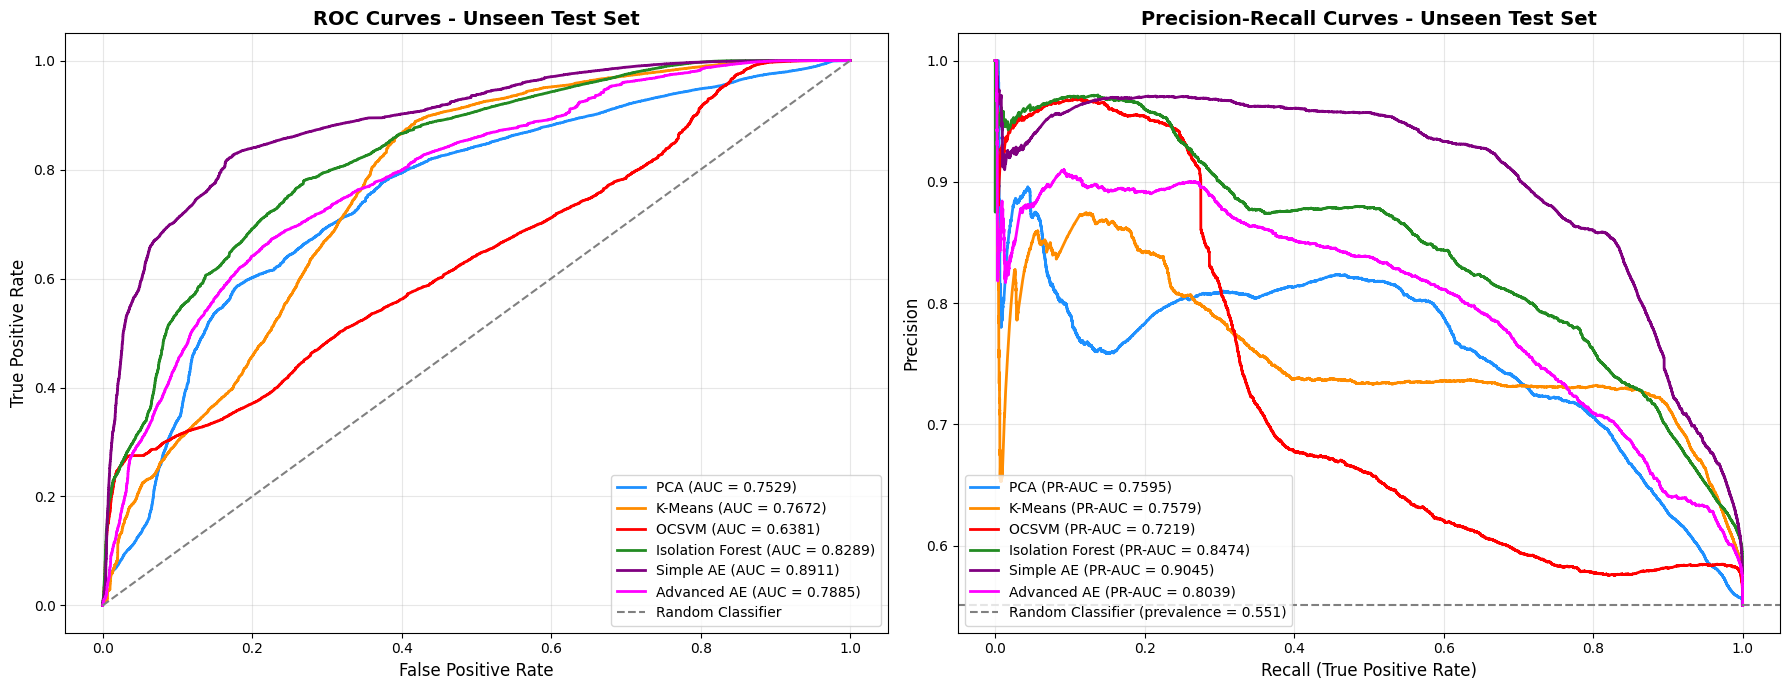

In [43]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score  # ← aggiunto roc_auc_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors = ['dodgerblue', 'darkorange', 'red', 'forestgreen', 'purple', 'magenta']

for (name, score), color in zip(test_scores.items(), colors):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = roc_auc_score(y_test, score)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2)

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, score)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})', color=color, lw=2)

# Formattazione ROC
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves - Unseen Test Set', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Formattazione PR — baseline = prevalenza attacchi nel test set
baseline_pr = y_test.mean()
ax2.axhline(y=baseline_pr, color='gray', linestyle='--',
            label=f'Random Classifier (prevalence = {baseline_pr:.3f})')
ax2.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves - Unseen Test Set', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Valutazione Operativa: Confusion Matrices

Applicando le soglie calibrate in Step 9 (95° percentile benigno, 5% FPR nominale),
ogni anomaly score continua viene binarizzata e valutata sul Test Set tramite
**Recall** (Detection Rate), **Precision** e **F1-Score** — le metriche operative
rilevanti in un contesto SOC, dove i ***False Negative*** hanno il costo più alto.

L'FPR empirico sul Test Set può differire dal 5% nominale: la soglia è stata
calibrata sul Validation Set, e qualsiasi shift distributivo tra i due set si
traduce in un FPR osservato diverso — comportamento atteso e metodologicamente
corretto. L'analisi per categoria di attacco è riportata nello Step successivo.


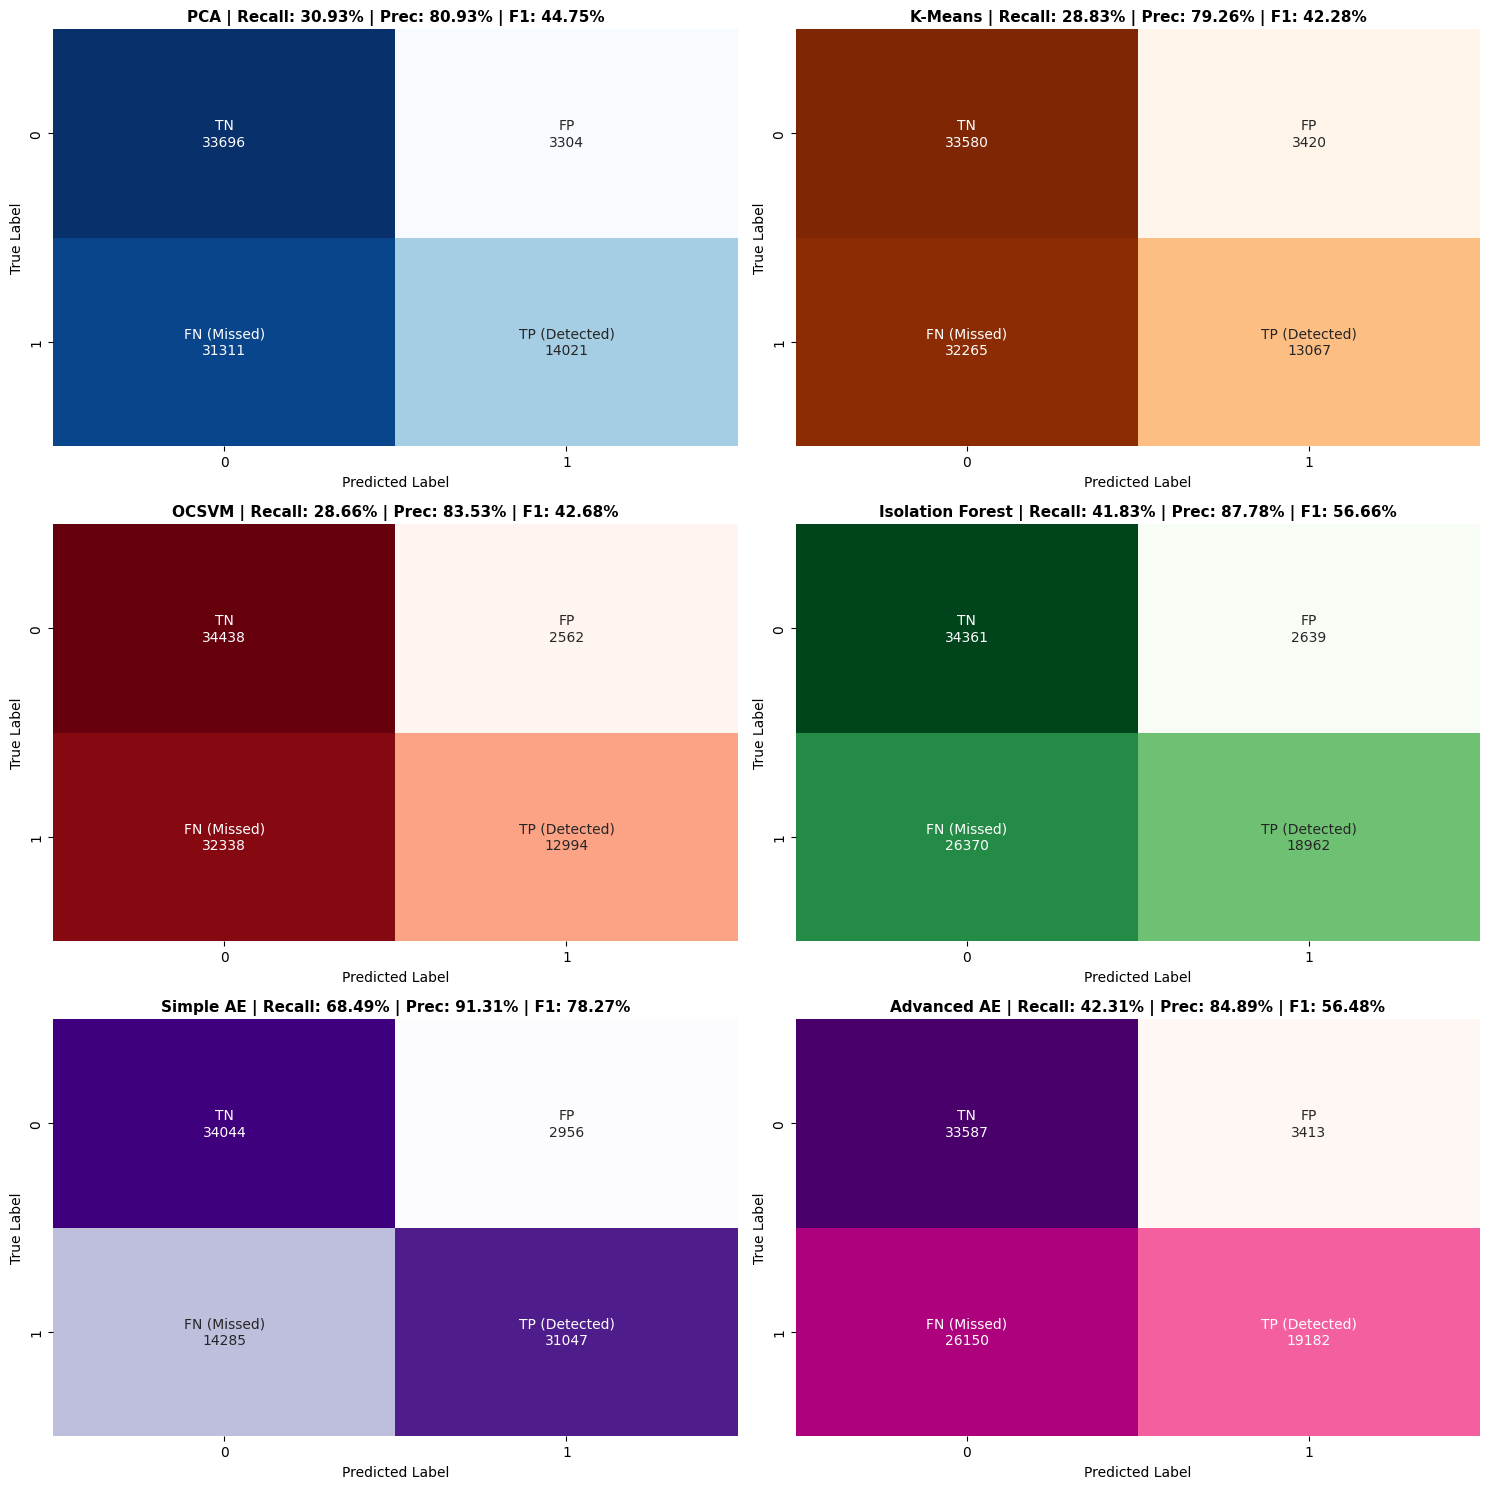


Model                  Recall  Precision       F1       TP       FP       FN       TN
----------------------------------------------------------------------------
PCA                    30.93%     80.93%   44.75%    14021     3304    31311    33696
K-Means                28.83%     79.26%   42.28%    13067     3420    32265    33580
OCSVM                  28.66%     83.53%   42.68%    12994     2562    32338    34438
Isolation Forest       41.83%     87.78%   56.66%    18962     2639    26370    34361
Simple AE              68.49%     91.31%   78.27%    31047     2956    14285    34044
Advanced AE            42.31%     84.89%   56.48%    19182     3413    26150    33587


In [44]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
cmaps = ['Blues', 'Oranges', 'Reds', 'Greens', 'Purples', 'RdPu']

for i, (name, score) in enumerate(test_scores.items()):
    y_pred = (score > thresholds[name]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    labels = np.array([f"TN\n{tn}", f"FP\n{fp}", f"FN (Missed)\n{fn}", f"TP (Detected)\n{tp}"]).reshape(2, 2)
    sns.heatmap(cm, annot=labels, fmt='', cmap=cmaps[i], ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} | Recall: {recall:.2%} | Prec: {precision:.2%} | F1: {f1:.2%}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Tabella riepilogativa
print(f"\n{'Model':<20} {'Recall':>8} {'Precision':>10} {'F1':>8} {'TP':>8} {'FP':>8} {'FN':>8} {'TN':>8}")
print("-" * 76)
for name, score in test_scores.items():
    y_pred = (score > thresholds[name]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    rec  = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{name:<20} {rec:>8.2%} {prec:>10.2%} {f1:>8.2%} {tp:>8} {fp:>8} {fn:>8} {tn:>8}")


## 12. Analisi Post-Hoc: Detection Rate per Categoria di Attacco

Oltre alle metriche globali, un'analisi granulare per **famiglia di attacco**
rivela i punti di forza e i blind spot specifici di ciascun modello. Per ogni
categoria presente nel Test Set, viene calcolato il **Recall** indipendente per
modello, usando le label `attack_cat` salvate in Step 2.

La tabella consente a un analista SOC di selezionare il modello più adatto
al proprio profilo di minaccia: categorie ad alto volume (Exploits, Fuzzers,
Reconnaissance) tendono a essere rilevate meglio di categorie rare ma critiche
(Backdoor, Shellcode, Worms), dove il basso numero di campioni penalizza
tutti i modelli unsupervised.


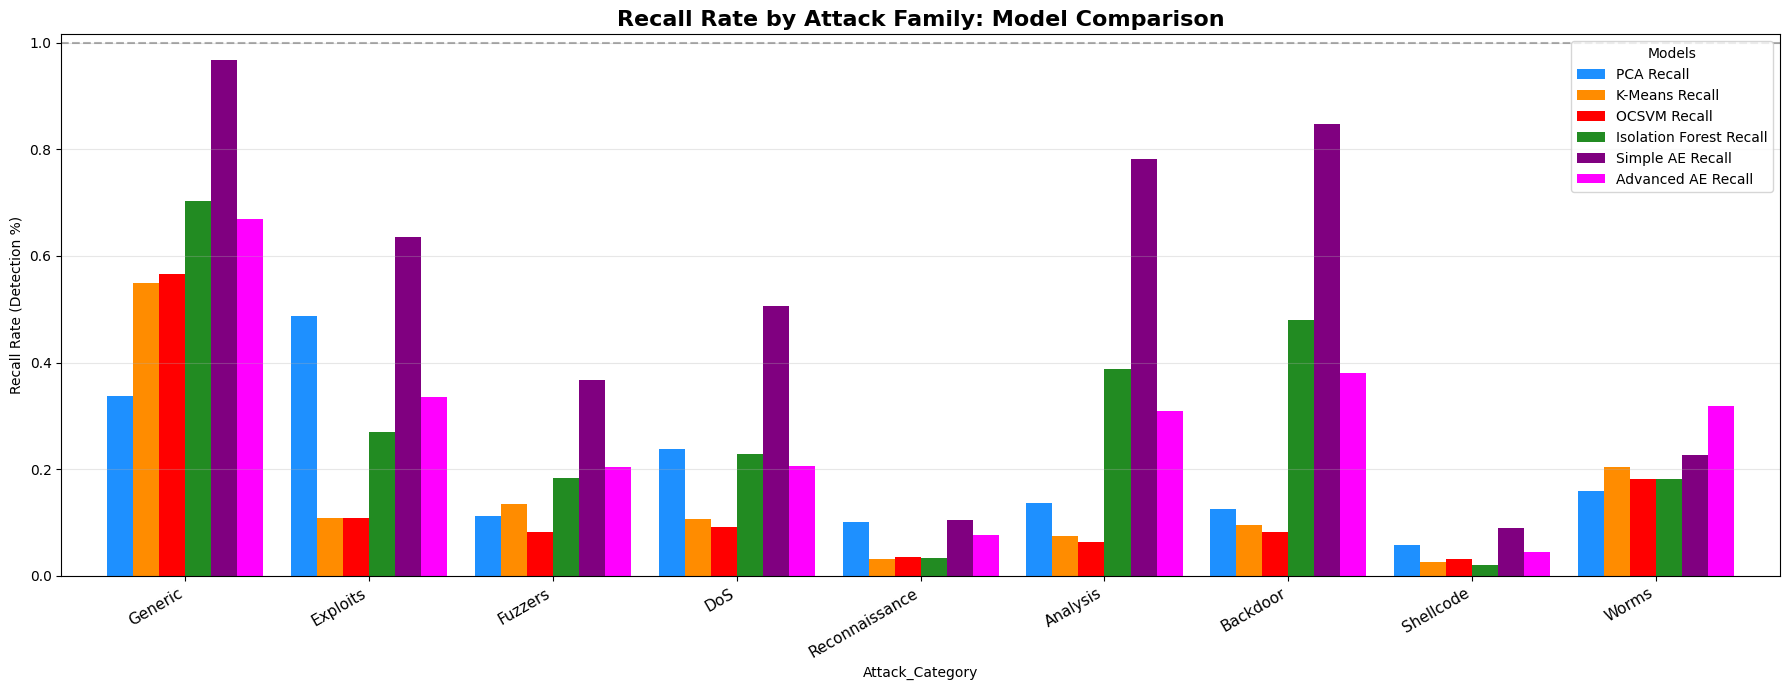


--- Detailed Recall Rates by Attack Category (Best in Bold) ---


,Total_Attacks,PCA Recall,K-Means Recall,OCSVM Recall,Isolation Forest Recall,Simple AE Recall,Advanced AE Recall
Attack_Category,,,,,,,
Generic,18871,0.338,0.549,0.566,0.702,0.967,0.670
Exploits,11132,0.488,0.109,0.108,0.269,0.635,0.335
Fuzzers,6062,0.113,0.135,0.082,0.183,0.368,0.204
DoS,4089,0.238,0.106,0.092,0.229,0.506,0.206
Reconnaissance,3496,0.101,0.031,0.035,0.033,0.104,0.076
Analysis,677,0.136,0.075,0.064,0.388,0.781,0.309
Backdoor,583,0.125,0.096,0.082,0.480,0.847,0.381
Shellcode,378,0.058,0.026,0.032,0.021,0.090,0.045
Worms,44,0.159,0.205,0.182,0.182,0.227,0.318


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Creazione DataFrame base — reset_index per allineare y_test e attack_cat_test
results_df = pd.DataFrame({
    'True_Label':      y_test,
    'Attack_Category': attack_cat_test.reset_index(drop=True).fillna('Normal')  # ← fix
})

# 2. Aggiunta predizioni
for name in test_scores.keys():
    results_df[f'Pred_{name}'] = (test_scores[name] > thresholds[name]).astype(int)

# 3. Filtro solo attacchi
attacks_only = results_df[results_df['True_Label'] == 1]

# 4. Calcolo Recall per categoria
recall_by_cat = attacks_only.groupby('Attack_Category').agg(
    Total_Attacks=('True_Label', 'count')
)

recall_cols = []
for name in test_scores.keys():
    detected_col   = attacks_only.groupby('Attack_Category')[f'Pred_{name}'].sum()
    recall_col_name = f'{name} Recall'
    recall_by_cat[recall_col_name] = (detected_col / recall_by_cat['Total_Attacks']).round(3)
    recall_cols.append(recall_col_name)

# 5. Ordinamento per frequenza
recall_by_cat = recall_by_cat.sort_values('Total_Attacks', ascending=False)

# --- GRAFICO ---
colors_6 = ['dodgerblue', 'darkorange', 'red', 'forestgreen', 'purple', 'magenta']
ax = recall_by_cat[recall_cols].plot(
    kind='bar', figsize=(18, 7), color=colors_6, width=0.85
)
plt.title('Recall Rate by Attack Family: Model Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Recall Rate (Detection %)')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Models', loc='upper right')
plt.tight_layout()
plt.show()

# --- TABELLA STYLING ---
print("\n--- Detailed Recall Rates by Attack Category (Best in Bold) ---")

def highlight_max_row(s):
    is_max = s == s.max()
    return ['font-weight: bold; background-color: #eaf2f8' if v else '' for v in is_max]

styled_recall = recall_by_cat.style.apply(
    highlight_max_row,
    axis=1,
    subset=recall_cols
).format(precision=3)

display(styled_recall)


## 13. Sensitivity Analysis: Selezione Data-Driven della Soglia di Correlazione

Per eliminare il bias umano nella scelta della soglia di correlazione, viene
eseguita una **Sensitivity Analysis**: la soglia di Pearson viene abbassata
iterativamente, eliminando le feature con correlazione massima a coppie superiore
al cutoff. Ad ogni iterazione tutti i modelli vengono riaddestrati e valutati
sul Validation Set — il Test Set rimane completamente isolato.

La matrice di correlazione è calcolata **esclusivamente sul Training Set benigno**;
lo `StandardScaler` viene fittato di nuovo ad ogni iterazione sulla feature space
ridotta (anti-leakage). L'algoritmo identifica come **Optimal Data-Driven Cut**
la soglia che massimizza la ROC-AUC media sul Validation Set: **0.80**, con
**28 feature** residue e un best model (Simple AE) a **AUC = 0.9016**.


Starting Sensitivity Analysis (Validation Phase)...

Methodological Check: Computing correlation strictly on 44800 BENIGN samples.
Evaluating performance strictly on VALIDATION SET to prevent Data Leakage.

Using tuned params:
  PCA n=30 | KMeans k=20 | OCSVM nu=0.01 | iForest n=200
  Simple AE  h1=48  h2=24  lr=0.0005  batch=512  epochs=60
  Advanced AE d1=32  d2=16  bottleneck=8  dropout=0.1  lr=0.0005
[*] Threshold: 0.95 → Features remaining: 32
[*] Threshold: 0.90 → Features remaining: 30
[*] Threshold: 0.85 → Features remaining: 29
[*] Threshold: 0.80 → Features remaining: 28
[*] Threshold: 0.75 → Features remaining: 27
[*] Threshold: 0.70 → Features remaining: 24

Computations completed! Calculating optimal data-driven threshold on VALIDATION set...
✅ Optimal Data-Driven Cut Found: 0.80
🏆 Best Performance (Validation): 0.9016 (Model: Simple AE)


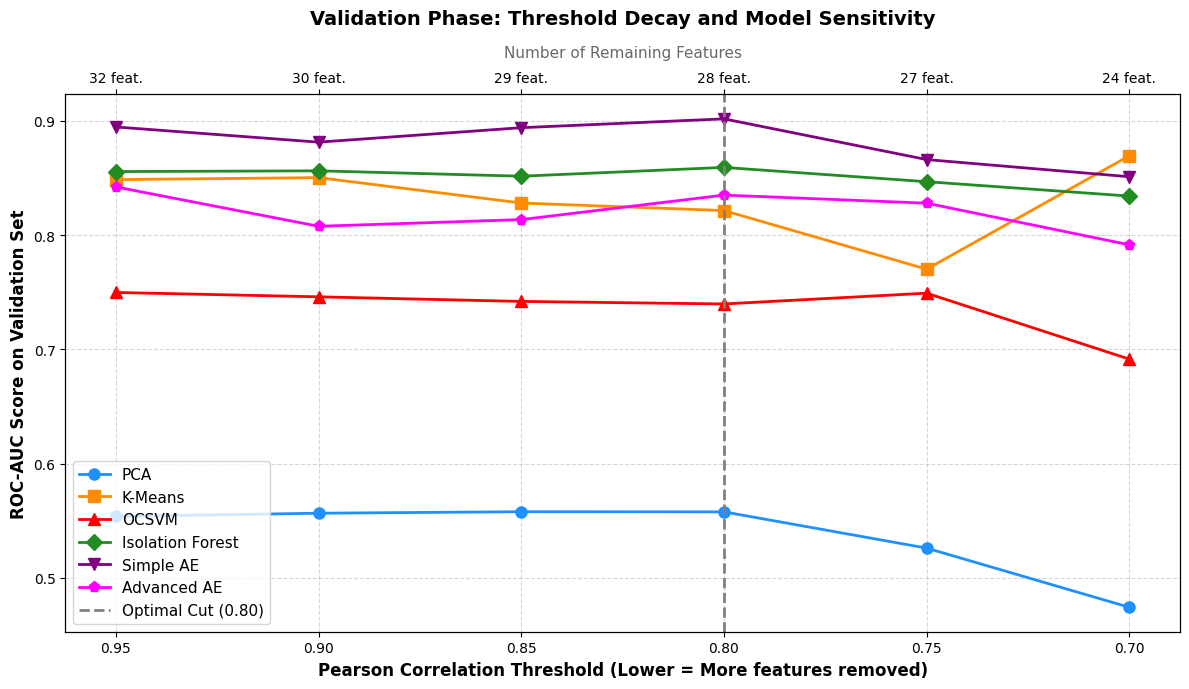

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import random
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ── SEEDING LOCALE ─────────────────────────────────────────────
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("Starting Sensitivity Analysis (Validation Phase)...\n")
print(f"Methodological Check: Computing correlation strictly on {X_train_mitre.shape[0]} BENIGN samples.")
print("Evaluating performance strictly on VALIDATION SET to prevent Data Leakage.")

# ── Estrazione parametri ottimali da best_params ──────────────
best_pca_n  = best_params['PCA'].get('n_components', 30)               if best_params['PCA']              != 'baseline' else 30
best_km_k   = best_params['K-Means'].get('n_clusters', 10)             if best_params['K-Means']          != 'baseline' else 10
best_svm_nu = best_params['OCSVM'].get('nu', 0.1)                      if best_params['OCSVM']            != 'baseline' else 0.1
best_if_n   = best_params['Isolation Forest'].get('n_estimators', 100) if best_params['Isolation Forest'] != 'baseline' else 100

# ── Estrazione parametri ottimali AE da best_params ──────────
# Simple AE
best_ae_h1     = best_params['Simple AE'].get('h1', 24)          if best_params['Simple AE']  != 'baseline' else 24
best_ae_h2     = best_params['Simple AE'].get('h2', 16)          if best_params['Simple AE']  != 'baseline' else 16
best_ae_lr     = best_params['Simple AE'].get('lr', 1e-3)        if best_params['Simple AE']  != 'baseline' else 1e-3
best_ae_batch  = best_params['Simple AE'].get('batch_size', 256) if best_params['Simple AE']  != 'baseline' else 256
best_ae_epochs = best_params['Simple AE'].get('epochs', 50)      if best_params['Simple AE']  != 'baseline' else 50

# Advanced AE
best_adv_d1         = best_params['Advanced AE'].get('d1', 32)           if best_params['Advanced AE'] != 'baseline' else 32
best_adv_d2         = best_params['Advanced AE'].get('d2', 16)           if best_params['Advanced AE'] != 'baseline' else 16
best_adv_bottleneck = best_params['Advanced AE'].get('bottleneck', 12)   if best_params['Advanced AE'] != 'baseline' else 12
best_adv_dropout    = best_params['Advanced AE'].get('dropout', 0.2)     if best_params['Advanced AE'] != 'baseline' else 0.2
best_adv_lr         = best_params['Advanced AE'].get('lr', 1e-3)         if best_params['Advanced AE'] != 'baseline' else 1e-3
best_adv_batch      = best_params['Advanced AE'].get('batch_size', 256)  if best_params['Advanced AE'] != 'baseline' else 256
best_adv_epochs     = best_params['Advanced AE'].get('epochs', 80)       if best_params['Advanced AE'] != 'baseline' else 80

print(f"\nUsing tuned params:")
print(f"  PCA n={best_pca_n} | KMeans k={best_km_k} | OCSVM nu={best_svm_nu} | iForest n={best_if_n}")
print(f"  Simple AE  h1={best_ae_h1}  h2={best_ae_h2}  lr={best_ae_lr}  batch={best_ae_batch}  epochs={best_ae_epochs}")
print(f"  Advanced AE d1={best_adv_d1}  d2={best_adv_d2}  bottleneck={best_adv_bottleneck}  dropout={best_adv_dropout}  lr={best_adv_lr}")

thresholds_to_test       = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70]
decay_results            = {m: [] for m in ['PCA', 'K-Means', 'OCSVM', 'Isolation Forest', 'Simple AE', 'Advanced AE']}
features_retained_counts = []

# Matrice di correlazione calcolata ESCLUSIVAMENTE sul Benign Training
corr_matrix = X_train_mitre.corr(method='pearson').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

for thresh in thresholds_to_test:
    # 1. Feature Drop
    to_drop      = [column for column in upper.columns if any(upper[column] > thresh)]
    X_train_dist = X_train_mitre.drop(columns=to_drop)
    X_val_dist   = X_val_mitre.drop(columns=to_drop)

    current_dim  = X_train_dist.shape[1]
    features_retained_counts.append(current_dim)
    print(f"[*] Threshold: {thresh:.2f} → Features remaining: {current_dim}")

    # 2. Scaling — fit SOLO sul benigno training
    scaler_dist         = StandardScaler()
    X_train_scaled_dist = scaler_dist.fit_transform(X_train_dist)
    X_val_scaled_dist   = scaler_dist.transform(X_val_dist)

    # 3. PCA
    pca_dist = PCA(n_components=min(best_pca_n, current_dim - 1), random_state=42).fit(X_train_scaled_dist)
    decay_results['PCA'].append(roc_auc_score(
        y_val,
        np.mean(np.power(X_val_scaled_dist - pca_dist.inverse_transform(
            pca_dist.transform(X_val_scaled_dist)), 2), axis=1)
    ))

    # 4. K-Means
    km_dist = MiniBatchKMeans(
        n_clusters=best_km_k, random_state=42, batch_size=2048, n_init=10
    ).fit(X_train_scaled_dist)
    decay_results['K-Means'].append(roc_auc_score(
        y_val, np.min(km_dist.transform(X_val_scaled_dist), axis=1)
    ))

    # 5. OCSVM
    svm_dist = OneClassSVM(kernel='rbf', gamma='scale', nu=best_svm_nu).fit(X_train_scaled_dist)
    decay_results['OCSVM'].append(roc_auc_score(
        y_val, -svm_dist.decision_function(X_val_scaled_dist)
    ))

    # 6. Isolation Forest
    if_dist = IsolationForest(
        n_estimators=best_if_n, contamination='auto', random_state=42, n_jobs=-1
    ).fit(X_train_scaled_dist)
    decay_results['Isolation Forest'].append(roc_auc_score(
        y_val, -if_dist.score_samples(X_val_scaled_dist)
    ))

    # ── Seed reset pre-Keras ──────────────────────────────────
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(42)

    # 7. Simple AE
    ae_simple = build_simple_ae(
        input_dim=current_dim,
        h1=best_ae_h1, h2=best_ae_h2, lr=best_ae_lr
    )
    es_simple = callbacks.EarlyStopping(
        monitor='loss', patience=4, restore_best_weights=True, min_delta=1e-5
    )
    rlr_simple = callbacks.ReduceLROnPlateau(
        monitor='loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0
    )
    ae_simple.fit(
        X_train_scaled_dist, X_train_scaled_dist,
        epochs=best_ae_epochs, batch_size=best_ae_batch,
        callbacks=[es_simple, rlr_simple], verbose=0
    )
    decay_results['Simple AE'].append(roc_auc_score(
        y_val,
        np.mean(np.power(X_val_scaled_dist - ae_simple.predict(
            X_val_scaled_dist, verbose=0), 2), axis=1)
    ))

    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(42)

    # 8. Advanced AE
    ae_adv = build_advanced_ae(
        input_dim=current_dim,
        d1=best_adv_d1, d2=best_adv_d2,
        bottleneck=best_adv_bottleneck,
        dropout=best_adv_dropout, lr=best_adv_lr
    )
    es_adv = callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, min_delta=1e-5
    )
    rlr_adv = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=0
    )
    ae_adv.fit(
        X_train_scaled_dist, X_train_scaled_dist,
        epochs=best_adv_epochs, batch_size=best_adv_batch,
        validation_split=0.1,
        callbacks=[es_adv, rlr_adv], verbose=0
    )
    decay_results['Advanced AE'].append(roc_auc_score(
        y_val,
        np.mean(np.power(X_val_scaled_dist - ae_adv.predict(
            X_val_scaled_dist, verbose=0), 2), axis=1)
    ))

    tf.keras.backend.clear_session()
    gc.collect()

print("\nComputations completed! Calculating optimal data-driven threshold on VALIDATION set...")

# ── Data-Driven Threshold Selection (MAX AUC) ─────────────────
max_auc_per_threshold = [
    np.max([decay_results[m][i] for m in decay_results])
    for i in range(len(thresholds_to_test))
]
best_thresh_idx    = np.argmax(max_auc_per_threshold)
best_thresh        = thresholds_to_test[best_thresh_idx]
best_model_at_peak = list(decay_results.keys())[
    np.argmax([decay_results[m][best_thresh_idx] for m in decay_results])
]

print(f"✅ Optimal Data-Driven Cut Found: {best_thresh:.2f}")
print(f"🏆 Best Performance (Validation): {max_auc_per_threshold[best_thresh_idx]:.4f} (Model: {best_model_at_peak})")

# ── Plot Decay Curves ─────────────────────────────────────────
plt.figure(figsize=(12, 7))
colors_6 = ['dodgerblue', 'darkorange', 'red', 'forestgreen', 'purple', 'magenta']
markers  = ['o', 's', '^', 'D', 'v', 'p']

for (model_name, auc_scores), color, marker in zip(decay_results.items(), colors_6, markers):
    plt.plot(thresholds_to_test, auc_scores, label=model_name, color=color,
             marker=marker, linewidth=2, markersize=8)

plt.axvline(x=best_thresh, color='gray', linestyle='--', linewidth=2,
            label=f'Optimal Cut ({best_thresh:.2f})')
plt.gca().invert_xaxis()
plt.xlabel('Pearson Correlation Threshold (Lower = More features removed)',
           fontsize=12, fontweight='bold')
plt.ylabel('ROC-AUC Score on Validation Set', fontsize=12, fontweight='bold')
plt.title('Validation Phase: Threshold Decay and Model Sensitivity',
          fontsize=14, fontweight='bold', pad=15)

ax1 = plt.gca()
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(thresholds_to_test)
ax2.set_xticklabels([f'{f} feat.' for f in features_retained_counts])
ax2.set_xlabel('Number of Remaining Features', fontsize=11, color='dimgray', labelpad=10)

ax1.legend(loc='lower left', fontsize=11)
ax1.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 14. Valutazione Finale Distillata sul Test Set Isolato

La sensitivity analysis ha identificato **0.80** come soglia ottimale, riducendo
la feature space da **37 a 28 variabili**. Le soglie operative vengono
**ricalibrate** sul setup distillato (95° percentile benigno, ~5% FPR nominale)
per garantire confronti operativi corretti.

I risultati sul Test Set rivelano un impatto **fortemente model-dependent**:
**K-Means** è l'unico modello che beneficia stabilmente della riduzione
(spazio di distanza più pulito, minor rischio di centroid collapse), mentre
**PCA** subisce la degradazione più severa — la rimozione delle componenti
correlate elimina le direzioni di varianza su cui il modello ricostruisce il
traffico normale. I modelli reconstruction-based e a ensemble mostrano
variazioni miste per categoria.

La configurazione originale a **37 feature MITRE** rimane la scelta superiore
per la maggior parte dei modelli. La configurazione distillata a 28 feature
è un'alternativa compatta per scenari con vincoli di risorse, con un esplicito
trade-off tra **compattezza** ed **efficacia di rilevamento**.


Executing Final Ablation Study at Optimal Data-Driven Threshold (0.80)...

Tuned AE params → Simple AE: 48→24→48 | Advanced AE: 32→16→8→16→32
Features retained: 28 / 37


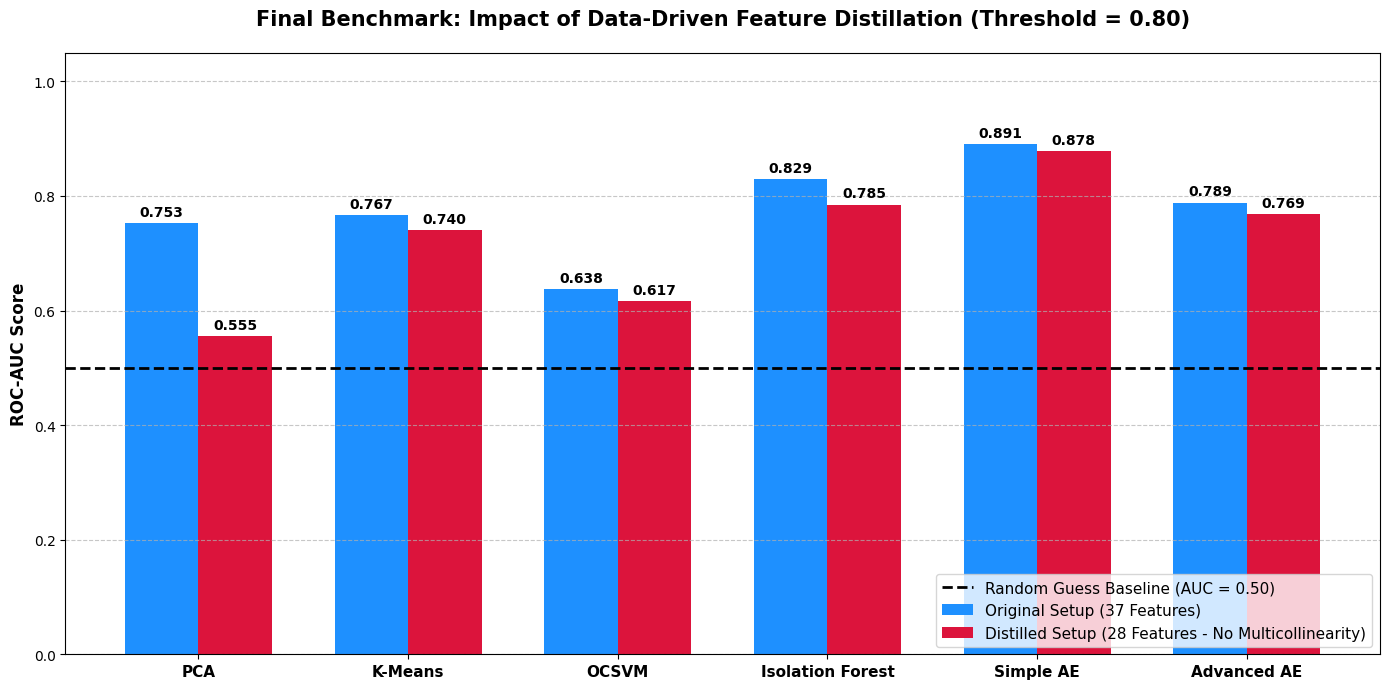


Thresholds ricalibrati per il setup distillato (95° pct benigni, ~5% FPR):
Model                  Threshold Distillato    Threshold Originale
------------------------------------------------------------------
PCA                                0.005781               0.009463
K-Means                            4.548821               5.321259
OCSVM                             -0.183138              -0.195906
Isolation Forest                   0.508004               0.430306
Simple AE                          0.009378               0.017138
Advanced AE                        0.212110               0.219811


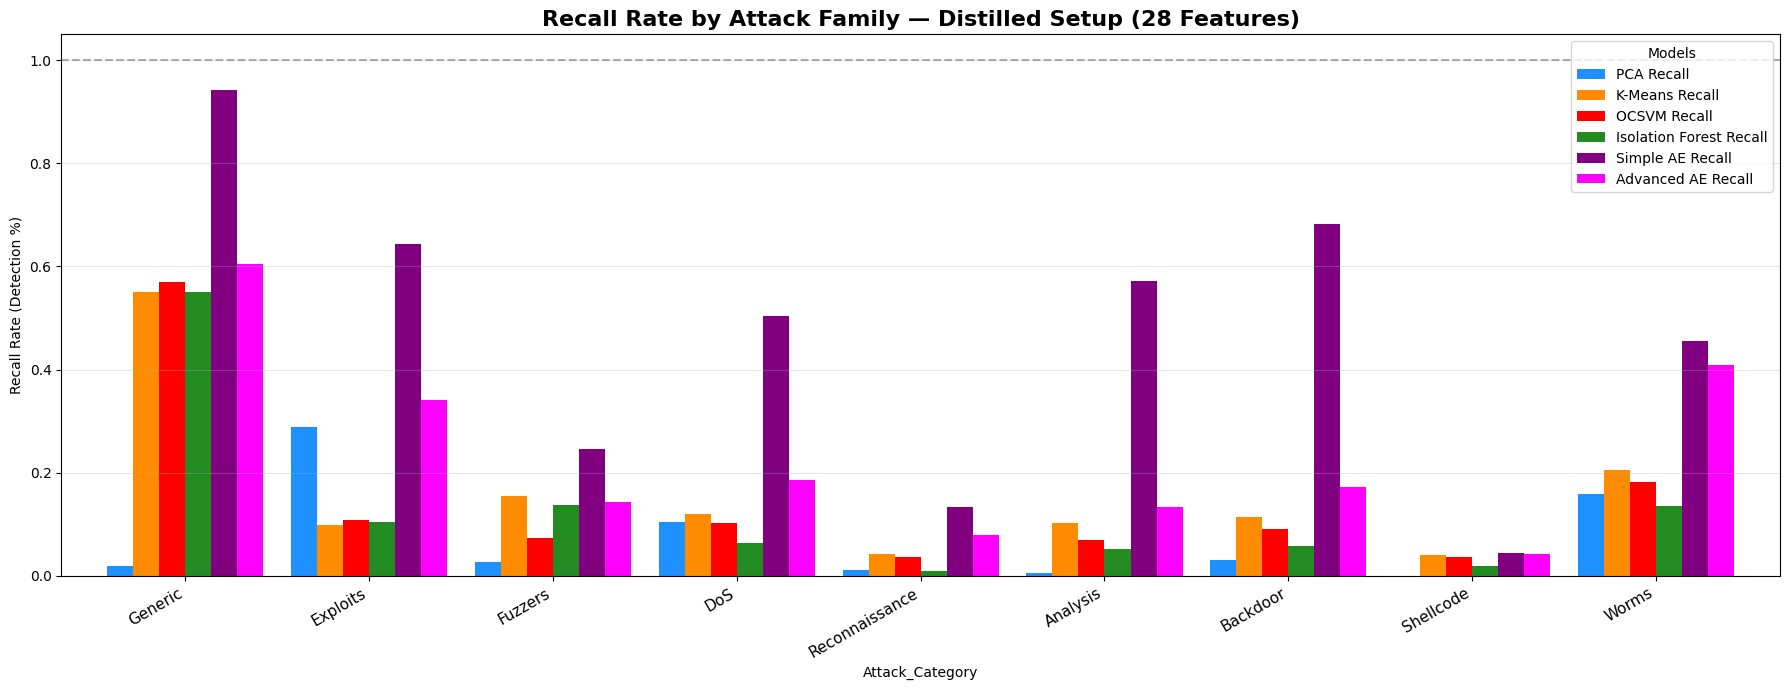


--- Recall by Attack Category — Distilled (soglie ricalibrate) ---


,Total_Attacks,PCA Recall,K-Means Recall,OCSVM Recall,Isolation Forest Recall,Simple AE Recall,Advanced AE Recall
Attack_Category,,,,,,,
Generic,18871,0.020,0.550,0.570,0.551,0.942,0.605
Exploits,11132,0.289,0.098,0.108,0.105,0.644,0.342
Fuzzers,6062,0.028,0.155,0.073,0.137,0.247,0.143
DoS,4089,0.104,0.120,0.102,0.064,0.503,0.187
Reconnaissance,3496,0.011,0.042,0.037,0.009,0.133,0.080
Analysis,677,0.006,0.102,0.069,0.052,0.572,0.134
Backdoor,583,0.031,0.115,0.091,0.058,0.683,0.172
Shellcode,378,0.000,0.040,0.037,0.019,0.045,0.042
Worms,44,0.159,0.205,0.182,0.136,0.455,0.409


In [47]:
import gc
import random

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print(f"Executing Final Ablation Study at Optimal Data-Driven Threshold ({best_thresh:.2f})...\n")

# ── Estrazione parametri ottimali da best_params ──────────────
best_pca_n  = best_params['PCA'].get('n_components', 30)               if best_params['PCA']              != 'baseline' else 30
best_km_k   = best_params['K-Means'].get('n_clusters', 10)             if best_params['K-Means']          != 'baseline' else 10
best_svm_nu = best_params['OCSVM'].get('nu', 0.1)                      if best_params['OCSVM']            != 'baseline' else 0.1
best_if_n   = best_params['Isolation Forest'].get('n_estimators', 100) if best_params['Isolation Forest'] != 'baseline' else 100

# ── Estrazione parametri ottimali AE da best_params ──────────
best_ae_h1     = best_params['Simple AE'].get('h1', 24)          if best_params['Simple AE']  != 'baseline' else 24
best_ae_h2     = best_params['Simple AE'].get('h2', 16)          if best_params['Simple AE']  != 'baseline' else 16
best_ae_lr     = best_params['Simple AE'].get('lr', 1e-3)        if best_params['Simple AE']  != 'baseline' else 1e-3
best_ae_batch  = best_params['Simple AE'].get('batch_size', 256) if best_params['Simple AE']  != 'baseline' else 256
best_ae_epochs = best_params['Simple AE'].get('epochs', 50)      if best_params['Simple AE']  != 'baseline' else 50

best_adv_d1         = best_params['Advanced AE'].get('d1', 32)           if best_params['Advanced AE'] != 'baseline' else 32
best_adv_d2         = best_params['Advanced AE'].get('d2', 16)           if best_params['Advanced AE'] != 'baseline' else 16
best_adv_bottleneck = best_params['Advanced AE'].get('bottleneck', 12)   if best_params['Advanced AE'] != 'baseline' else 12
best_adv_dropout    = best_params['Advanced AE'].get('dropout', 0.2)     if best_params['Advanced AE'] != 'baseline' else 0.2
best_adv_lr         = best_params['Advanced AE'].get('lr', 1e-3)         if best_params['Advanced AE'] != 'baseline' else 1e-3
best_adv_batch      = best_params['Advanced AE'].get('batch_size', 256)  if best_params['Advanced AE'] != 'baseline' else 256
best_adv_epochs     = best_params['Advanced AE'].get('epochs', 80)       if best_params['Advanced AE'] != 'baseline' else 80

print(f"Tuned AE params → Simple AE: {best_ae_h1}→{best_ae_h2}→{best_ae_h1} | Advanced AE: {best_adv_d1}→{best_adv_d2}→{best_adv_bottleneck}→{best_adv_d2}→{best_adv_d1}")

# ── Feature Drop alla soglia ottimale ─────────────────────────
to_drop_opt        = [column for column in upper.columns if any(upper[column] > best_thresh)]
X_train_opt        = X_train_mitre.drop(columns=to_drop_opt)
X_val_opt          = X_val_mitre.drop(columns=to_drop_opt)
X_test_opt         = X_test_mitre.drop(columns=to_drop_opt)

scaler_opt         = StandardScaler()
X_train_scaled_opt = scaler_opt.fit_transform(X_train_opt)
X_val_scaled_opt   = scaler_opt.transform(X_val_opt)
X_test_scaled_opt  = scaler_opt.transform(X_test_opt)

print(f"Features retained: {X_train_opt.shape[1]} / {X_train_mitre.shape[1]}")

results_opt   = {}
input_dim_opt = X_train_scaled_opt.shape[1]

# ── PCA ───────────────────────────────────────────────────────
pca_opt = PCA(
    n_components=min(best_pca_n, input_dim_opt - 1), random_state=42
).fit(X_train_scaled_opt)
results_opt['PCA'] = roc_auc_score(
    y_test,
    np.mean(np.power(
        X_test_scaled_opt - pca_opt.inverse_transform(
            pca_opt.transform(X_test_scaled_opt)), 2), axis=1)
)

# ── K-Means ───────────────────────────────────────────────────
km_opt = MiniBatchKMeans(
    n_clusters=best_km_k, random_state=42, batch_size=2048, n_init=10
).fit(X_train_scaled_opt)
results_opt['K-Means'] = roc_auc_score(
    y_test, np.min(km_opt.transform(X_test_scaled_opt), axis=1)
)

# ── OCSVM ─────────────────────────────────────────────────────
svm_opt = OneClassSVM(
    kernel='rbf', gamma='scale', nu=best_svm_nu
).fit(X_train_scaled_opt)
results_opt['OCSVM'] = roc_auc_score(
    y_test, -svm_opt.decision_function(X_test_scaled_opt)
)

# ── Isolation Forest ──────────────────────────────────────────
if_opt = IsolationForest(
    n_estimators=best_if_n, contamination='auto', random_state=42, n_jobs=-1
).fit(X_train_scaled_opt)
results_opt['Isolation Forest'] = roc_auc_score(
    y_test, -if_opt.score_samples(X_test_scaled_opt)
)

# ── Simple AE — architettura tuned da Cell 8 ✅ ───────────────
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

ae_simple_opt = build_simple_ae(
    input_dim=input_dim_opt,
    h1=best_ae_h1, h2=best_ae_h2, lr=best_ae_lr
)
es_simple_opt = callbacks.EarlyStopping(
    monitor='loss', patience=4, restore_best_weights=True, min_delta=1e-5
)
rlr_simple_opt = callbacks.ReduceLROnPlateau(
    monitor='loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0
)
ae_simple_opt.fit(
    X_train_scaled_opt, X_train_scaled_opt,
    epochs=best_ae_epochs, batch_size=best_ae_batch,
    callbacks=[es_simple_opt, rlr_simple_opt], verbose=0
)
results_opt['Simple AE'] = roc_auc_score(
    y_test,
    np.mean(np.power(
        X_test_scaled_opt - ae_simple_opt.predict(
            X_test_scaled_opt, verbose=0), 2), axis=1)
)

# ── Advanced AE — architettura tuned da Cell 8 ✅ ─────────────
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

ae_adv_opt = build_advanced_ae(
    input_dim=input_dim_opt,
    d1=best_adv_d1, d2=best_adv_d2,
    bottleneck=best_adv_bottleneck,
    dropout=best_adv_dropout, lr=best_adv_lr
)
es_adv_opt = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, min_delta=1e-5
)
rlr_adv_opt = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=0
)
ae_adv_opt.fit(
    X_train_scaled_opt, X_train_scaled_opt,
    epochs=best_adv_epochs, batch_size=best_adv_batch,
    validation_split=0.1,
    callbacks=[es_adv_opt, rlr_adv_opt], verbose=0
)
results_opt['Advanced AE'] = roc_auc_score(
    y_test,
    np.mean(np.power(
        X_test_scaled_opt - ae_adv_opt.predict(
            X_test_scaled_opt, verbose=0), 2), axis=1)
)

# ── Memory Clean ──────────────────────────────────────────────
tf.keras.backend.clear_session()
_ = gc.collect()

# ── Grafico a barre affiancate ────────────────────────────────
labels             = ['PCA', 'K-Means', 'OCSVM', 'Isolation Forest', 'Simple AE', 'Advanced AE']
auc_original       = [roc_auc_score(y_test, test_scores[l]) for l in labels]
auc_distilled_list = [results_opt[l] for l in labels]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, auc_original,       width,
                label='Original Setup (37 Features)', color='dodgerblue')
rects2 = ax.bar(x + width/2, auc_distilled_list, width,
                label=f'Distilled Setup ({X_train_opt.shape[1]} Features - No Multicollinearity)',
                color='crimson')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2,
           label='Random Guess Baseline (AUC = 0.50)')
ax.set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_title(
    f'Final Benchmark: Impact of Data-Driven Feature Distillation (Threshold = {best_thresh:.2f})',
    fontsize=15, fontweight='bold', pad=20
)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# RECALL BY ATTACK CATEGORY — Distilled
# ══════════════════════════════════════════════════════════════

test_scores_opt = {
    'PCA': np.mean(np.power(
        X_test_scaled_opt - pca_opt.inverse_transform(
            pca_opt.transform(X_test_scaled_opt)), 2), axis=1),
    'K-Means':          np.min(km_opt.transform(X_test_scaled_opt), axis=1),
    'OCSVM':            -svm_opt.decision_function(X_test_scaled_opt),
    'Isolation Forest': -if_opt.score_samples(X_test_scaled_opt),
    'Simple AE': np.mean(np.power(
        X_test_scaled_opt - ae_simple_opt.predict(
            X_test_scaled_opt, verbose=0), 2), axis=1),
    'Advanced AE': np.mean(np.power(
        X_test_scaled_opt - ae_adv_opt.predict(
            X_test_scaled_opt, verbose=0), 2), axis=1),
}

# ── Ricalibrazione soglie (95° pct benigni) ───────────────────
val_scores_opt = {
    'PCA': np.mean(np.power(
        X_val_scaled_opt - pca_opt.inverse_transform(
            pca_opt.transform(X_val_scaled_opt)), 2), axis=1),
    'K-Means':          np.min(km_opt.transform(X_val_scaled_opt), axis=1),
    'OCSVM':            -svm_opt.decision_function(X_val_scaled_opt),
    'Isolation Forest': -if_opt.score_samples(X_val_scaled_opt),
    'Simple AE': np.mean(np.power(
        X_val_scaled_opt - ae_simple_opt.predict(
            X_val_scaled_opt, verbose=0), 2), axis=1),
    'Advanced AE': np.mean(np.power(
        X_val_scaled_opt - ae_adv_opt.predict(
            X_val_scaled_opt, verbose=0), 2), axis=1),
}

thresholds_opt = {
    name: np.percentile(val_scores_opt[name][y_val == 0], 95)
    for name in val_scores_opt
}

print("\nThresholds ricalibrati per il setup distillato (95° pct benigni, ~5% FPR):")
print(f"{'Model':<20} {'Threshold Distillato':>22} {'Threshold Originale':>22}")
print("-" * 66)
for name in thresholds_opt:
    print(f"{name:<20} {thresholds_opt[name]:>22.6f} {thresholds[name]:>22.6f}")

# ── Predizioni binarie ────────────────────────────────────────
results_df_opt = pd.DataFrame({
    'True_Label':      y_test,
    'Attack_Category': attack_cat_test.reset_index(drop=True).fillna('Normal')
})

for name in test_scores_opt.keys():
    results_df_opt[f'Pred_{name}'] = (
        test_scores_opt[name] > thresholds_opt[name]
    ).astype(int)

attacks_only_opt = results_df_opt[results_df_opt['True_Label'] == 1]

recall_by_cat_opt = attacks_only_opt.groupby('Attack_Category').agg(
    Total_Attacks=('True_Label', 'count')
)

recall_cols_opt = []
for name in test_scores_opt.keys():
    detected_col    = attacks_only_opt.groupby('Attack_Category')[f'Pred_{name}'].sum()
    recall_col_name = f'{name} Recall'
    recall_by_cat_opt[recall_col_name] = (
        detected_col / recall_by_cat_opt['Total_Attacks']
    ).round(3)
    recall_cols_opt.append(recall_col_name)

recall_by_cat_opt = recall_by_cat_opt.sort_values('Total_Attacks', ascending=False)

colors_6 = ['dodgerblue', 'darkorange', 'red', 'forestgreen', 'purple', 'magenta']

ax_recall_opt = recall_by_cat_opt[recall_cols_opt].plot(
    kind='bar', figsize=(18, 7), color=colors_6, width=0.85
)
plt.title(
    f'Recall Rate by Attack Family — Distilled Setup ({X_train_opt.shape[1]} Features)',
    fontsize=16, fontweight='bold'
)
plt.ylabel('Recall Rate (Detection %)')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Models', loc='upper right')
plt.tight_layout()
plt.show()

print("\n--- Recall by Attack Category — Distilled (soglie ricalibrate) ---")
styled_recall_opt = recall_by_cat_opt.style.apply(
    highlight_max_row, axis=1, subset=recall_cols_opt
).format(precision=3)
display(styled_recall_opt)


## 15. Copertura MITRE ATT&CK dopo la Feature Distillation

Con la soglia ottimale **0.80**, la feature space si riduce da **37 a 28 variabili**
(9 feature rimosse). Questa sezione rivaluta il subset distillato dal punto di
vista della copertura **MITRE ATT&CK**, verificando se la visibilità tattica sulla
Cyber Kill Chain viene preservata.

Un effetto rilevante emerge dall'analisi: le feature rimosse non eliminano intere
prospettive tattiche, poiché il loro ruolo è parzialmente assorbito da feature
residue che fungono da **behavioral proxies**. La configurazione distillata
preserva la copertura a livello di tattica per le principali aree ATT&CK considerate
— Reconnaissance, Command & Control, Exfiltration — nonostante la riduzione.

Tuttavia, la **copertura tattica non implica copertura a livello di tecnica**: le
singole TTPs precedentemente coperte da più feature ridondanti ora dipendono da
un unico proxy, riducendo la robustezza di rilevamento per quella specifica
tecnica. Come confermato in Step 14, preservare la rappresentazione tattica non
garantisce performance equivalenti — la scelta tra le due configurazioni è
operativa, non metodologica.


🛡️ MITRE ATT&CK THREAT INTELLIGENCE ANALYSIS 🛡️
Generating TTP mapping table for features removed at Threshold 0.80...

✅ Copertura MITRE completa: 37 feature mappate.



MITRE Tactic,MITRE Technique,Original Features (37),❌ Removed by Pearson,✅ Retained (TTP Coverage)
RECONNAISSANCE,T1046: Network Service Scanning,"dur, spkts, dpkts, ct_srv_src, ct_state_ttl, ct_dst_ltm, ct_src_dport_ltm, ct_dst_sport_ltm, ct_dst_src_ltm, ct_srv_dst","dpkts, ct_dst_src_ltm, ct_srv_dst","dur, spkts, ct_srv_src, ct_state_ttl, ct_dst_ltm, ct_src_dport_ltm, ct_dst_sport_ltm"
CREDENTIAL ACCESS,T1110: Brute Force / Guessing,is_ftp_login,-,is_ftp_login
DISCOVERY,T1016: System Network Configuration Discovery,"sttl, dttl",-,"sttl, dttl"
COMMAND AND CONTROL,T1071.001: Web Traffic,"trans_depth, ct_flw_http_mthd",-,"trans_depth, ct_flw_http_mthd"
COMMAND AND CONTROL,T1071.002: File Transfer Protocols,ct_ftp_cmd,ct_ftp_cmd,-
COMMAND AND CONTROL,T1071: Application Layer Protocol,"sinpkt, dinpkt, sjit, djit, swin, dwin, stcpb, dtcpb, tcprtt, synack, ackdat","dwin, synack, ackdat","sinpkt, dinpkt, sjit, djit, swin, stcpb, dtcpb, tcprtt"
EXFILTRATION,T1048: Exfiltration Over Alternative Protocol,"sbytes, dbytes, sload, dload, smean, dmean, response_body_len",dbytes,"sbytes, sload, dload, smean, dmean, response_body_len"
IMPACT,T1498: Network Denial of Service,"rate, sloss, dloss",dloss,"rate, sloss"


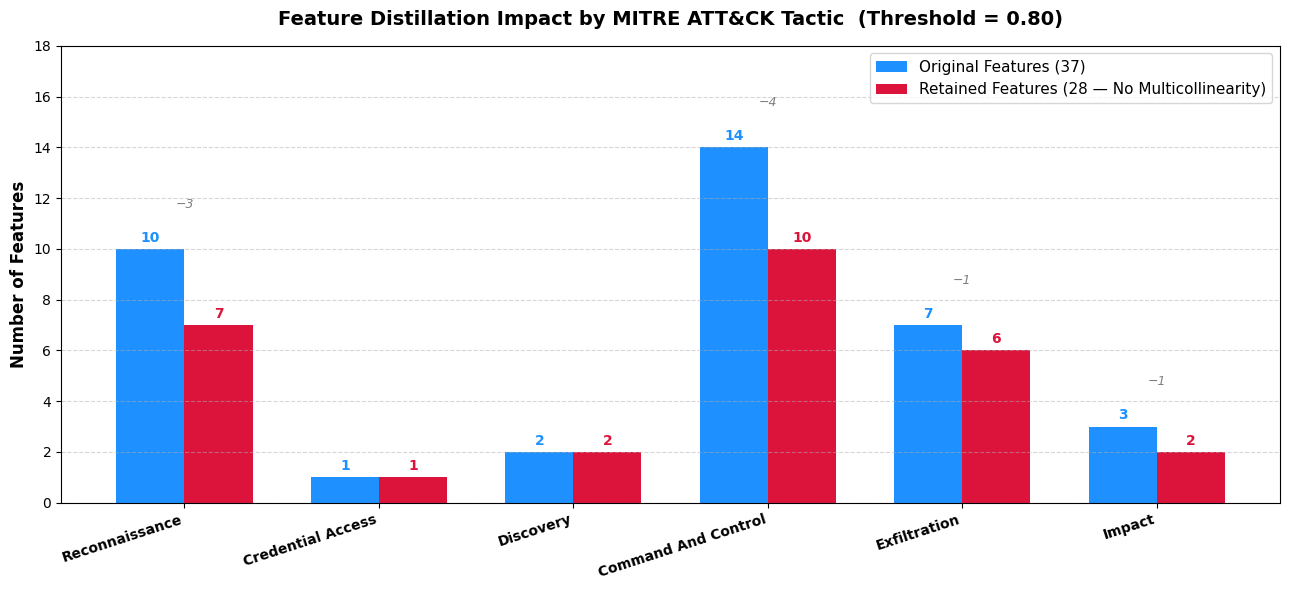

In [48]:
import pandas as pd
from IPython.display import display, HTML

print("🛡️ MITRE ATT&CK THREAT INTELLIGENCE ANALYSIS 🛡️")
print(f"Generating TTP mapping table for features removed at Threshold {best_thresh:.2f}...\n")

# ── Ricalcolo difensivo upper (nel caso cella eseguita in isolamento) ──────
corr_matrix = X_train_mitre.corr(method='pearson').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

mitre_mapping = {
    'dur':               ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'spkts':             ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'dpkts':             ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_srv_src':        ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_state_ttl':      ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_dst_ltm':        ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_src_dport_ltm':  ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_dst_sport_ltm':  ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_dst_src_ltm':    ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'ct_srv_dst':        ('Reconnaissance',      'T1046',     'Network Service Scanning'),
    'is_ftp_login':      ('Credential Access',   'T1110',     'Brute Force / Guessing'),
    'sttl':              ('Discovery',           'T1016',     'System Network Configuration Discovery'),
    'dttl':              ('Discovery',           'T1016',     'System Network Configuration Discovery'),
    'trans_depth':       ('Command and Control', 'T1071.001', 'Web Traffic'),
    'ct_flw_http_mthd':  ('Command and Control', 'T1071.001', 'Web Traffic'),
    'sinpkt':            ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'dinpkt':            ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'sjit':              ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'djit':              ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'swin':              ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'dwin':              ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'stcpb':             ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'dtcpb':             ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'tcprtt':            ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'synack':            ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'ackdat':            ('Command and Control', 'T1071',     'Application Layer Protocol'),
    'ct_ftp_cmd':        ('Command and Control', 'T1071.002', 'File Transfer Protocols'),
    'sbytes':            ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'dbytes':            ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'sload':             ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'dload':             ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'smean':             ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'dmean':             ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'response_body_len': ('Exfiltration',        'T1048',     'Exfiltration Over Alternative Protocol'),
    'rate':              ('Impact',              'T1498',     'Network Denial of Service'),
    'sloss':             ('Impact',              'T1498',     'Network Denial of Service'),
    'dloss':             ('Impact',              'T1498',     'Network Denial of Service'),
}

# ── Check difensivo copertura features ────────────────────────
mapped   = set(mitre_mapping.keys())
selected = set(features_mitre)
if mapped != selected:
    print(f"⚠️ Non mappate: {selected - mapped}")
    print(f"⚠️ Orfane:      {mapped - selected}")
else:
    print(f"✅ Copertura MITRE completa: {len(mapped)} feature mappate.\n")

# ── Feature drop alla soglia ottimale ─────────────────────────
to_drop_opt = [column for column in upper.columns if any(upper[column] > best_thresh)]

records = []
for feat, (tactic, tid, tname) in mitre_mapping.items():
    records.append({
        'MITRE Tactic':     tactic.upper(),
        'MITRE Technique':  f"{tid}: {tname}",
        'Feature':          feat,
        'Removed':          feat in to_drop_opt
    })

df_mitre = pd.DataFrame(records)

def aggregate_features(g):
    original = ', '.join(g['Feature'])
    removed  = ', '.join(g[g['Removed']]['Feature'])  if any(g['Removed'])  else '-'
    retained = ', '.join(g[~g['Removed']]['Feature']) if any(~g['Removed']) else '-'
    return pd.Series({
        'Original Features (37)':    original,
        '❌ Removed by Pearson':      removed,
        '✅ Retained (TTP Coverage)': retained
    })

summary_table = df_mitre.groupby(
    ['MITRE Tactic', 'MITRE Technique'], as_index=False
).apply(aggregate_features).reset_index(drop=True)

# ── Ordinamento Cyber Kill Chain ──────────────────────────────
kill_chain_order = [
    'RECONNAISSANCE', 'CREDENTIAL ACCESS', 'DISCOVERY',
    'COMMAND AND CONTROL', 'EXFILTRATION', 'IMPACT'
]
summary_table['MITRE Tactic'] = pd.Categorical(
    summary_table['MITRE Tactic'], categories=kill_chain_order, ordered=True
)
summary_table = summary_table.sort_values(by=['MITRE Tactic', 'MITRE Technique'])

# ── Styling ───────────────────────────────────────────────────
tactic_colors = {
    'RECONNAISSANCE':     '#eaf2f8',
    'CREDENTIAL ACCESS':  '#f2f3f4',
    'DISCOVERY':          '#e8f8f5',
    'COMMAND AND CONTROL':'#f4ecf7',
    'EXFILTRATION':       '#fef9e7',
    'IMPACT':             '#fdedec'
}

def style_row_by_tactic(row):
    bg_color = tactic_colors.get(row['MITRE Tactic'], '#ffffff')
    styles = [f'background-color: {bg_color}; border-bottom: 1px solid #d5d8dc; vertical-align: middle;'] * len(row)
    for i, col in enumerate(row.index):
        if col == 'MITRE Tactic':
            styles[i] += ' font-weight: bold; font-size: 13px; color: #2c3e50;'
        elif '❌' in col:
            styles[i] += ' color: #a6acaf; font-style: italic;' if row[col] == '-' else ' color: #c0392b; font-weight: bold;'
        elif '✅' in col:
            styles[i] += ' color: #a6acaf; font-style: italic;' if row[col] == '-' else ' color: #27ae60; font-weight: bold;'
    return styles

styled_table = summary_table.style \
    .apply(style_row_by_tactic, axis=1) \
    .hide(axis="index") \
    .set_properties(**{
        'text-align':   'left',
        'white-space':  'pre-wrap',
        'padding':      '8px 12px',
        'font-family':  'sans-serif'
    }) \
    .set_table_styles([dict(selector='th', props=[
        ('text-align',       'left'),
        ('background-color', '#2c3e50'),
        ('color',            'white'),
        ('font-size',        '14px'),
        ('padding',          '12px'),
        ('font-family',      'sans-serif')
    ])])

display(styled_table)

# ══════════════════════════════════════════════════════════════
# FEATURE DISTILLATION IMPACT — Bar Chart per MITRE Tactic
# Stessa palette blu/rosso del Final Benchmark (Cella 14)
# ══════════════════════════════════════════════════════════════

tactic_stats = df_mitre.groupby('MITRE Tactic').agg(
    Original=('Feature', 'count'),
    Retained=('Removed', lambda x: (~x).sum())
).reset_index()

# Ordina per Kill Chain (coerente con la tabella sopra)
tactic_stats['MITRE Tactic'] = pd.Categorical(
    tactic_stats['MITRE Tactic'], categories=kill_chain_order, ordered=True
)
tactic_stats = tactic_stats.sort_values('MITRE Tactic').reset_index(drop=True)
tactic_stats['Removed_count'] = tactic_stats['Original'] - tactic_stats['Retained']

x     = np.arange(len(tactic_stats))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

rects1 = ax.bar(x - width/2, tactic_stats['Original'], width,
                label=f'Original Features (37)',
                color='dodgerblue')
rects2 = ax.bar(x + width/2, tactic_stats['Retained'], width,
                label=f'Retained Features ({X_train_opt.shape[1]} — No Multicollinearity)',
                color='crimson')

ax.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
ax.set_title(
    f'Feature Distillation Impact by MITRE ATT&CK Tactic  (Threshold = {best_thresh:.2f})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(
    [t.title() for t in tactic_stats['MITRE Tactic']],
    fontsize=10, fontweight='bold', rotation=18, ha='right'
)
ax.set_ylim(0, tactic_stats['Original'].max() + 4)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Annotazioni valori + delta rimossi
for i, (r1, r2) in enumerate(zip(rects1, rects2)):
    # valore barra originale
    ax.annotate(f"{int(r1.get_height())}",
                xy=(r1.get_x() + r1.get_width() / 2, r1.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=10,
                fontweight='bold', color='dodgerblue')
    # valore barra retained
    ax.annotate(f"{int(r2.get_height())}",
                xy=(r2.get_x() + r2.get_width() / 2, r2.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=10,
                fontweight='bold', color='crimson')
    # delta rimossi centrato tra le due barre
    removed = int(tactic_stats.loc[i, 'Removed_count'])
    if removed > 0:
        mid_x   = (r1.get_x() + r1.get_width() / 2 + r2.get_x() + r2.get_width() / 2) / 2
        top_y   = max(r1.get_height(), r2.get_height()) + 1.5
        ax.annotate(f"−{removed}",
                    xy=(mid_x, top_y),
                    ha='center', va='bottom', fontsize=9,
                    color='gray', style='italic')

plt.tight_layout()
plt.show()



## 16. Supervised Upper Bound — XGBoost come Riferimento SOTA

La letteratura SOTA su UNSW-NB15 è dominata da approcci **supervisionati**:
gradient boosting classifiers come XGBoost e LightGBM raggiungono
ROC-AUC > 0.999 e F1 > 0.98 con accesso completo alle label di attacco
(Bansal et al., 2025; Kasongo & Sun, 2020). Per ancorare empiricamente i
nostri risultati a questo riferimento, introduciamo un classificatore
**XGBoost** addestrato sui medesimi feature space (37 e 28 feature MITRE).

A differenza dei modelli unsupervised, XGBoost riceve le **label complete**
durante il training. Lo scaler viene di conseguenza fittato sull'intero
training set (benigno + attacchi), riflettendo l'accesso distributivo più
ampio disponibile nel paradigma supervisionato.

**Questo non è un confronto equo.** Serve a due scopi: quantificare il
**gap rispetto alla SOTA** supervisionata sulla stessa pipeline e stesso
test set, e misurare il **costo dell'assenza di label** — la penalità di
performance reale del paradigma Novelty Detection in scenari zero-day.
XGBoost viene addestrato con iperparametri fissi (no tuning), rappresentando
un **upper bound approssimato**, non un sistema supervisionato ottimizzato.


  STEP 16 — SUPERVISED UPPER BOUND
  XGBoost vs Simple AE (Best Unsupervised)

Training XGBoost (37 feat) su 140,272 campioni etichettati...
Training XGBoost (28 feat)...

  XGBoost (37 feat)          AUC=0.9839   AP=0.9882
  XGBoost (28 feat)          AUC=0.9770   AP=0.9834
  Simple AE (37 feat)        AUC=0.8911   AP=0.9046
  Simple AE (28 feat)        AUC=0.8777   AP=0.9009


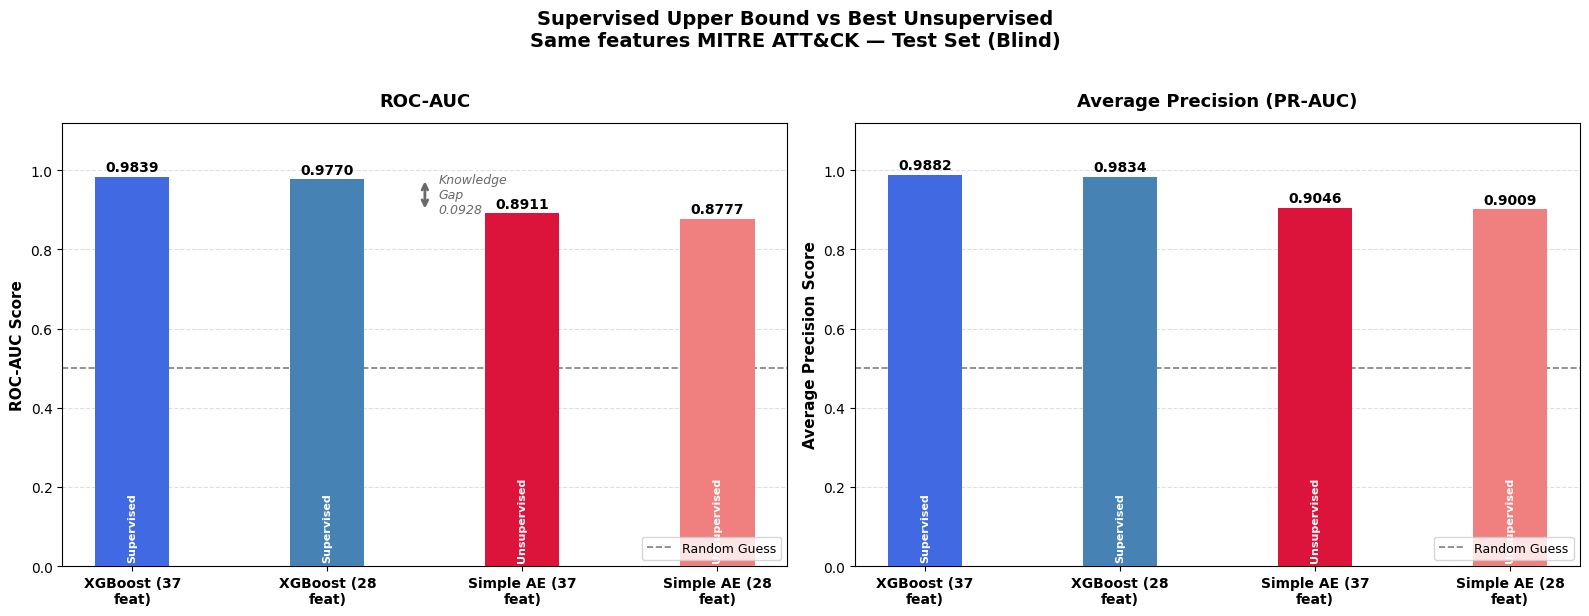

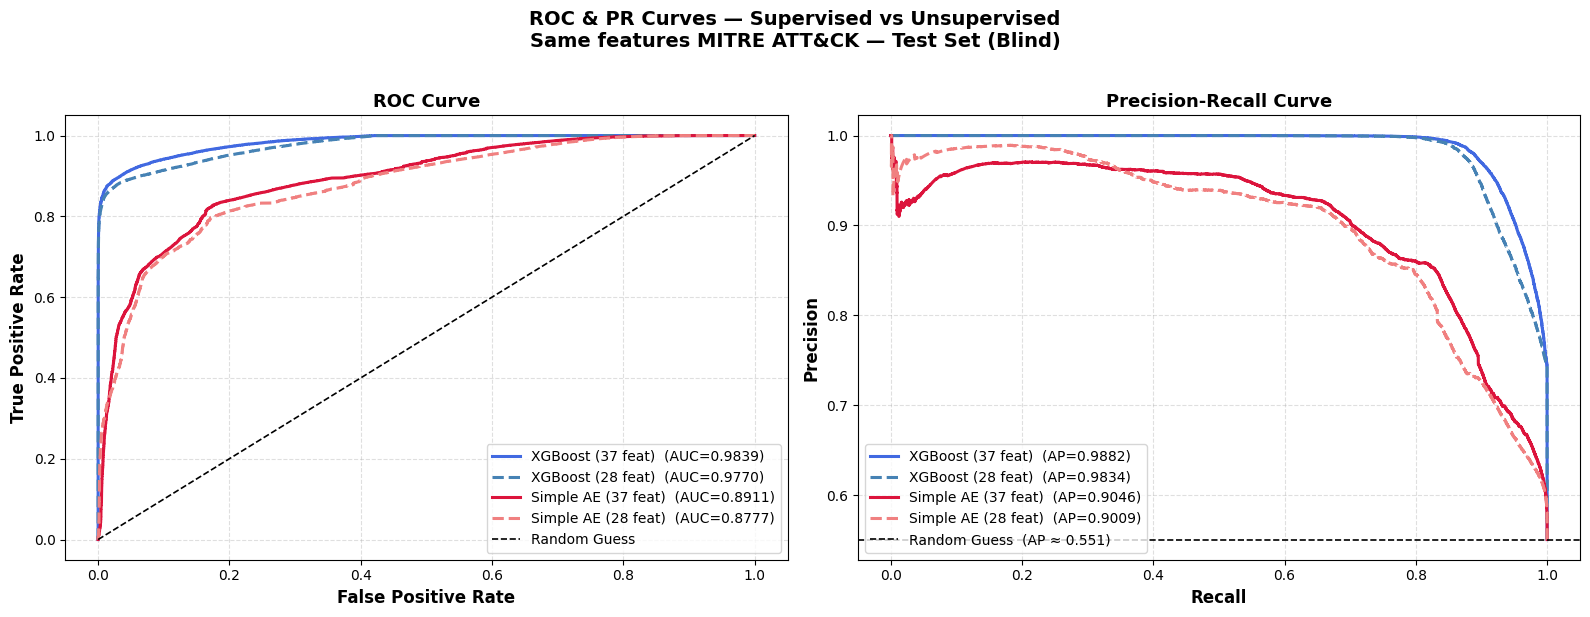

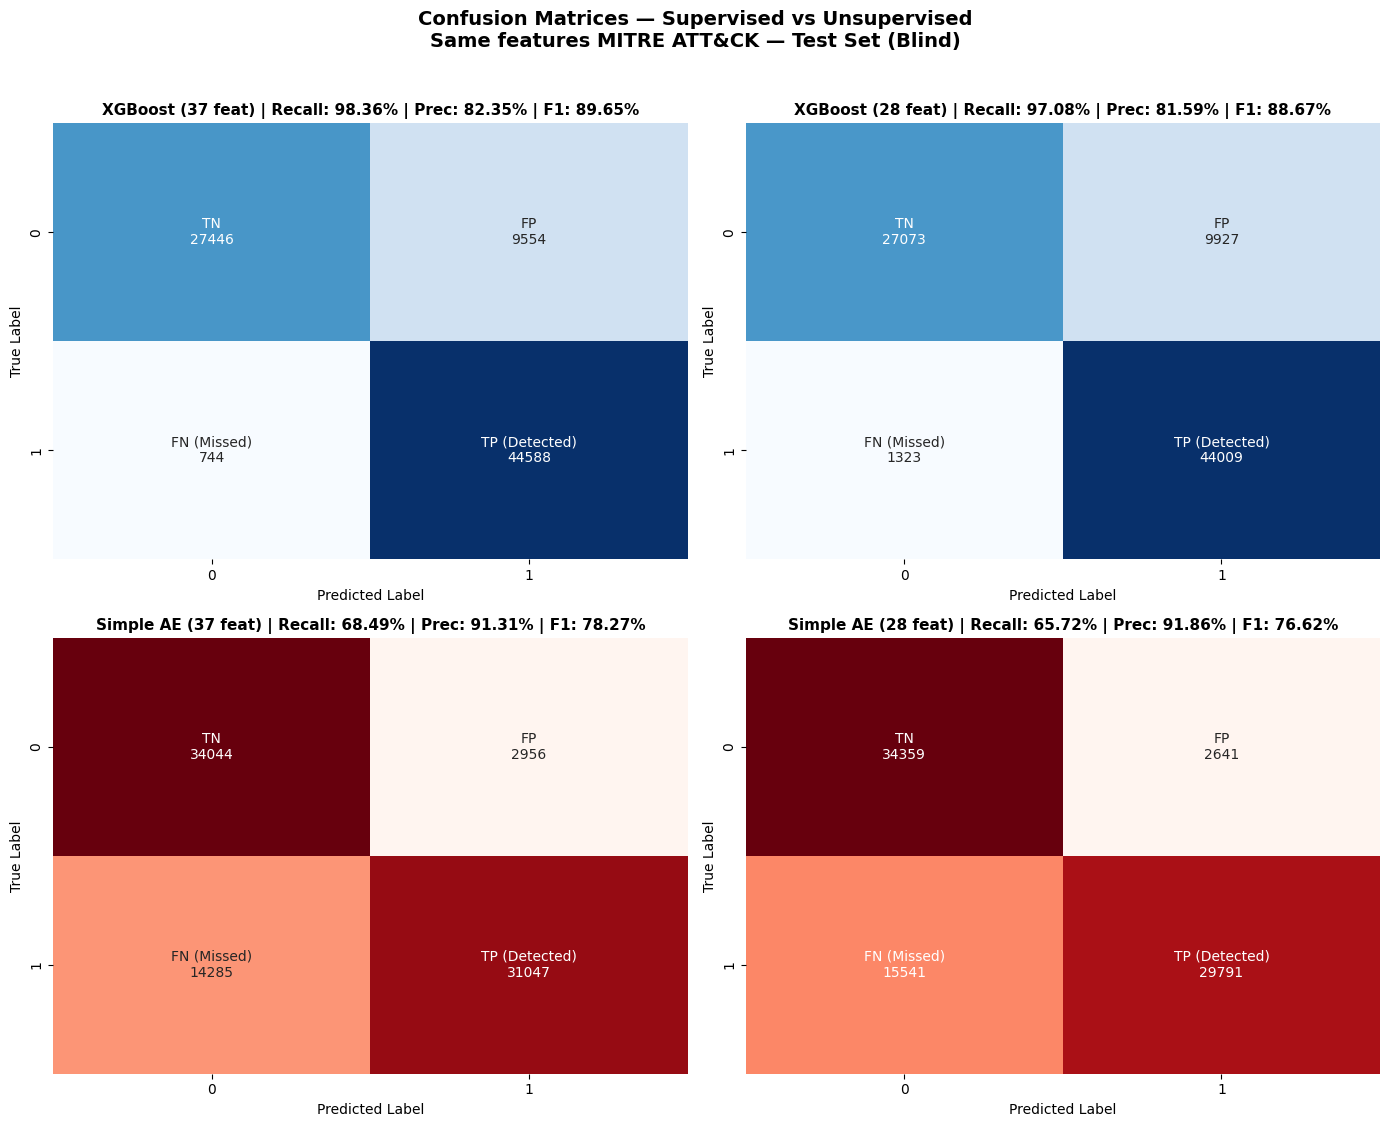


Model                       Recall  Precision       F1       TP       FP       FN       TN
-------------------------------------------------------------------------------------
XGBoost (37 feat)           98.36%     82.35%   89.65%    44588     9554      744    27446
XGBoost (28 feat)           97.08%     81.59%   88.67%    44009     9927     1323    27073
Simple AE (37 feat)         68.49%     91.31%   78.27%    31047     2956    14285    34044
Simple AE (28 feat)         65.72%     91.86%   76.62%    29791     2641    15541    34359


In [49]:
import random
import gc
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix
)

random.seed(42)
np.random.seed(42)

print("=" * 60)
print("  STEP 16 — SUPERVISED UPPER BOUND")
print("  XGBoost vs Simple AE (Best Unsupervised)")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# 1. DATASET SUPERVISED
# ══════════════════════════════════════════════════════════════
# NOTA METODOLOGICA: gli scaler supervisionati vengono fittati
# su TUTTI i 140.272 campioni di training (benigni + attacchi),
# a differenza dello scaler unsupervised che era fittato
# esclusivamente sui 44.800 campioni benigni.
# Questa asimmetria è intenzionale e riflette i diversi paradigmi:
# nel setting supervisionato il modello ha pieno accesso alla
# distribuzione del traffico, inclusi gli attacchi.

X_train_sup_37 = train_df_num[features_mitre].reset_index(drop=True)
X_train_sup_28 = train_df_num[features_mitre].drop(
    columns=to_drop_opt).reset_index(drop=True)

scaler_sup_37         = StandardScaler()
X_train_scaled_sup_37 = scaler_sup_37.fit_transform(X_train_sup_37)
X_test_scaled_sup_37  = scaler_sup_37.transform(
    X_test_mitre.reset_index(drop=True))

scaler_sup_28         = StandardScaler()
X_train_scaled_sup_28 = scaler_sup_28.fit_transform(X_train_sup_28)
X_test_scaled_sup_28  = scaler_sup_28.transform(
    X_test_mitre.drop(columns=to_drop_opt).reset_index(drop=True))

# ══════════════════════════════════════════════════════════════
# 2. XGBOOST — Supervised Reference (SOTA tabular su UNSW-NB15)
#
# Parametri fissi: nessun tuning su validation set.
# Rappresenta un upper bound approssimativo, non ottimizzato.
#
# Nota tecnica: XGBoost è tree-based e invariante allo scaling;
# la standardizzazione è mantenuta per coerenza con il pipeline,
# senza impatto sulle performance del modello.
#
# Riferimento SOTA: Bansal et al. (2025) — AUC ≈ 0.9996 su UNSW-NB15
# ══════════════════════════════════════════════════════════════
xgb_params = dict(
    n_estimators   = 200,
    max_depth      = 6,
    learning_rate  = 0.1,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    eval_metric    = 'logloss',
    random_state   = 42,
    n_jobs         = -1
)

print(f"\nTraining XGBoost (37 feat) su {X_train_sup_37.shape[0]:,} campioni etichettati...")
xgb_37 = XGBClassifier(**xgb_params).fit(X_train_scaled_sup_37, y_train_full)

print(f"Training XGBoost (28 feat)...")
xgb_28 = XGBClassifier(**xgb_params).fit(X_train_scaled_sup_28, y_train_full)

xgb_proba_37 = xgb_37.predict_proba(X_test_scaled_sup_37)[:, 1]
xgb_proba_28 = xgb_28.predict_proba(X_test_scaled_sup_28)[:, 1]

# ══════════════════════════════════════════════════════════════
# 3. METRICHE ROC-AUC e Average Precision
# ══════════════════════════════════════════════════════════════
metrics = {
    'XGBoost (37 feat)':   (xgb_proba_37,                 'royalblue',  '-' ),
    'XGBoost (28 feat)':   (xgb_proba_28,                 'steelblue',  '--'),
    'Simple AE (37 feat)': (test_scores['Simple AE'],      'crimson',    '-' ),
    'Simple AE (28 feat)': (test_scores_opt['Simple AE'],  'lightcoral', '--'),
}

auc_scores = {k: roc_auc_score(y_test, v[0])           for k, v in metrics.items()}
ap_scores  = {k: average_precision_score(y_test, v[0]) for k, v in metrics.items()}

print()
for k in metrics:
    print(f"  {k:<25}  AUC={auc_scores[k]:.4f}   AP={ap_scores[k]:.4f}")

# ══════════════════════════════════════════════════════════════
# FIGURA 1 — Bar chart AUC + AP (Knowledge Gap)
# ══════════════════════════════════════════════════════════════
labels_bar = list(metrics.keys())
colors_bar = [v[1] for v in metrics.values()]
auc_vals   = [auc_scores[k] for k in labels_bar]
ap_vals    = [ap_scores[k]  for k in labels_bar]
x          = np.arange(len(labels_bar))
width      = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, vals, metric_name, ylbl in zip(
    axes,
    [auc_vals, ap_vals],
    ['ROC-AUC', 'Average Precision (PR-AUC)'],
    ['ROC-AUC Score', 'Average Precision Score']
):
    bars = ax.bar(x, vals, color=colors_bar, width=width, zorder=3)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2,
               alpha=0.5, label='Random Guess')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [l.replace(' feat)', '\nfeat)') for l in labels_bar],
        fontsize=10, fontweight='bold'
    )
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(ylbl, fontsize=11, fontweight='bold')
    ax.set_title(metric_name, fontsize=13, fontweight='bold', pad=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(fontsize=9, loc='lower right')

    paradigms = ['Supervised', 'Supervised', 'Unsupervised', 'Unsupervised']
    for bar, val, par in zip(bars, vals, paradigms):
        ax.annotate(f'{val:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, val),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')
        ax.annotate(par,
                    xy=(bar.get_x() + bar.get_width() / 2, 0.01),
                    ha='center', fontsize=8, color='white', fontweight='bold',
                    rotation=90, va='bottom')

# Freccia Knowledge Gap — posizionata tra i due gruppi
ax_auc   = axes[0]
best_sup = max(auc_scores['XGBoost (37 feat)'], auc_scores['XGBoost (28 feat)'])
best_uns = max(auc_scores['Simple AE (37 feat)'], auc_scores['Simple AE (28 feat)'])
gap      = best_sup - best_uns
arrow_x  = 1.5  # tra gruppo supervised (0-1) e unsupervised (2-3)
ax_auc.annotate('',
                xy=(arrow_x, best_uns + 0.005),
                xytext=(arrow_x, best_sup - 0.005),
                arrowprops=dict(arrowstyle='<->', color='dimgray', lw=2))
ax_auc.text(arrow_x + 0.07, (best_sup + best_uns) / 2,
            f'Knowledge\nGap\n{gap:.4f}',
            ha='left', va='center', fontsize=9,
            color='dimgray', fontstyle='italic')

fig.suptitle(
    'Supervised Upper Bound vs Best Unsupervised\n'
    'Same features MITRE ATT&CK — Test Set (Blind)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# FIGURA 2 — ROC + PR Curves affiancate
# ══════════════════════════════════════════════════════════════
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))

for name, (score, color, ls) in metrics.items():
    fpr, tpr, _  = roc_curve(y_test, score)
    prec, rec, _ = precision_recall_curve(y_test, score)
    ax_roc.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.2,
                label=f'{name}  (AUC={auc_scores[name]:.4f})')
    ax_pr.plot(rec, prec, color=color, linestyle=ls, linewidth=2.2,
               label=f'{name}  (AP={ap_scores[name]:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Guess')
ax_roc.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate',  fontsize=12, fontweight='bold')
ax_roc.set_title('ROC Curve',            fontsize=13, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.grid(linestyle='--', alpha=0.4)

prevalence = float(y_test.mean())
ax_pr.axhline(prevalence, color='k', linestyle='--', linewidth=1.2,
              label=f'Random Guess  (AP ≈ {prevalence:.3f})')
ax_pr.set_xlabel('Recall',    fontsize=12, fontweight='bold')
ax_pr.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax_pr.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax_pr.legend(loc='lower left', fontsize=10)
ax_pr.grid(linestyle='--', alpha=0.4)

fig.suptitle(
    'ROC & PR Curves — Supervised vs Unsupervised\n'
    'Same features MITRE ATT&CK — Test Set (Blind)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# FIGURA 3 — Confusion Matrices
# ══════════════════════════════════════════════════════════════
cm_data = {
    'XGBoost (37 feat)':   xgb_37.predict(X_test_scaled_sup_37),
    'XGBoost (28 feat)':   xgb_28.predict(X_test_scaled_sup_28),
    'Simple AE (37 feat)': (test_scores['Simple AE']     > thresholds['Simple AE']).astype(int),
    'Simple AE (28 feat)': (test_scores_opt['Simple AE'] > thresholds_opt['Simple AE']).astype(int),
}
cmaps_16 = ['Blues', 'Blues', 'Reds', 'Reds']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(cm_data.items()):
    cm             = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall         = tp / (tp + fn)
    precision      = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1             = 2 * (precision * recall) / (precision + recall) \
                     if (precision + recall) > 0 else 0.0

    labels = np.array([
        f"TN\n{tn}",          f"FP\n{fp}",
        f"FN (Missed)\n{fn}", f"TP (Detected)\n{tp}"
    ]).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap=cmaps_16[i],
                ax=axes[i], cbar=False)
    axes[i].set_title(
        f'{name} | Recall: {recall:.2%} | Prec: {precision:.2%} | F1: {f1:.2%}',
        fontsize=11, fontweight='bold'
    )
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

fig.suptitle(
    'Confusion Matrices — Supervised vs Unsupervised\n'
    'Same features MITRE ATT&CK — Test Set (Blind)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Tabella riepilogativa ──────────────────────────────────────
print(f"\n{'Model':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} "
      f"{'TP':>8} {'FP':>8} {'FN':>8} {'TN':>8}")
print("-" * 85)
for name, y_pred in cm_data.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    rec  = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{name:<25} {rec:>8.2%} {prec:>10.2%} {f1:>8.2%} "
          f"{tp:>8} {fp:>8} {fn:>8} {tn:>8}")

# ── Memory Clean ──────────────────────────────────────────────
del X_train_scaled_sup_37, X_train_scaled_sup_28
_ = gc.collect()


## 17. Conclusioni e Sviluppi Futuri

Questo studio dimostra empiricamente che il paradigma **Novelty Detection**
— addestrando esclusivamente su traffico benigno — è in grado di rilevare
traffico anomalo con ROC-AUC fino a **0.901** (Simple AE, 37 feature **MITRE**),
con un gap misurabile rispetto all'*upper bound* supervisionato XGBoost.
Il **Simple Autoencoder** e **Isolation Forest** si confermano i modelli più
robusti dell'intera pipeline, mentre la feature distillation a 28 variabili
porta benefici solo per K-Means, a fronte di degradazioni per i modelli
reconstruction-based.

Per una transizione verso un deployment operativo reale in un **SOC**, la
priorità è spostare la calibrazione delle soglie dalla soglia al 5% FPR
usata in questo benchmark verso target operativi di **FPR < 1%** (idealmente
< 0.1%). La **Base Rate Fallacy** rende questo passaggio non opzionale: in
reti enterprise con milioni di eventi giornalieri, anche un FPR dell'1%
genera decine di migliaia di falsi allarmi al giorno, portando inevitabilmente
ad **Alert Fatigue** e degradazione dell'efficacia operativa.

Le direzioni di sviluppo futuro più promettenti sono due: la calibrazione
operativa delle soglie su FPR target realistici, e l'integrazione di
**architetture ensemble o ibride** che combinino i punti di forza del Simple
Autoencoder (rilevamento reconstruction-based) con la robustezza strutturale
di Isolation Forest — verso un sistema di rilevamento anomalie azionabile e
non solo statisticamente valido.
